<a href="https://colab.research.google.com/github/BABUKARTHIKRG/AI-for-Medicine-Specialization/blob/master/Copy_of_FedViT_LLM_XAI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FedViT-LLM-XAI
### A Privacy-Preserving Federated Vision Transformer Framework with Explainable Large Language Models for Multi-Class Skin Lesion Diagnosis

This notebook implements and evaluates **FedViT-LLM-XAI**, a federated learning framework that:

1. Trains a **ViT-B/16** backbone across simulated clients using a novel **Adaptive Confidence-Weighted Federated Averaging (ACW-FedAvg)** aggregation strategy.
2. Benchmarks against **centralized** models (ResNet-50, DenseNet-121, EfficientNet-B3, ViT-B/16, Swin-T).
3. Benchmarks against **federated algorithms** (FedAvg, FedProx, SCAFFOLD, FedNova, FedAdam, FedDyn).
4. Benchmarks against **privacy-aware methods** (DP-FedAvg, Secure Aggregation).
5. Runs an **ablation** ("FAR-ACW-Fed") that fixes the ViT backbone and data partitions while swapping only the aggregation rule — isolating the effect of ACW-FedAvg itself.
6. Produces **explainability** outputs (Grad-CAM, Attention Rollout, SHAP) and turns them into natural-language diagnostic reports via an **LLM explanation module**.
7. Reports **accuracy, robustness, fairness, privacy leakage, communication cost, and explainability quality**.

> **Data note:** The notebook is written against the **HAM10000** ("Human Against Machine") skin lesion dataset (7 classes: akiec, bcc, bkl, df, mel, nv, vasc). Because Colab has no pre-mounted dataset, this notebook:
> - Gives you the exact Kaggle download cell to pull the real data, **or**
> - Falls back to a synthetic-but-structurally-realistic dataset generator so every cell below runs end-to-end for pipeline validation even without dataset access.
>
> Just set `USE_REAL_DATA = True/False` in the config cell.

Runtime: **GPU (A100/T4) recommended**. Colab menu: `Runtime > Change runtime type > GPU`.


## 1. Environment Setup

In [1]:
# Core installs. Re-run once, then restart runtime if prompted.
!pip uninstall -y shap matplotlib numpy pytorch-grad-cam grad-cam # Aggressive uninstall

# Attempt to install pytorch-grad-cam first without version constraint
# If this fails with 'No matching distribution found', this part of XAI will be blocked.
!pip install -q pytorch-grad-cam

# Install other core libraries, allowing pip to resolve versions for shap/matplotlib
!pip install -q timm==0.9.16 opacus==1.4.0 torchmetrics==1.3.2 captum==0.7.0 kaggle==1.6.12 fairlearn==0.10.0
!pip install -q shap --upgrade # Try to get the latest shap compatible with existing numpy/python
!pip install -q matplotlib --upgrade # Ensure matplotlib is up-to-date or compatible
print("Install complete. Please restart the runtime.")

Found existing installation: shap 0.52.0
Uninstalling shap-0.52.0:
  Successfully uninstalled shap-0.52.0
Found existing installation: matplotlib 3.10.0
Uninstalling matplotlib-3.10.0:
  Successfully uninstalled matplotlib-3.10.0
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
ERROR: Could not find a version that satisfies the requirement pytorch-grad-cam (from versions: none)
ERROR: No matching distribution found for pytorch-grad-cam
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.7/79.7 kB 6.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 72.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.8/224.8 kB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 841.5/841.5 kB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 55.8 MB/

In [5]:
import os, io, json, math, time, random, copy, warnings, hashlib
from dataclasses import dataclass, field
from collections import OrderedDict, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset

import timm
import torchmetrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, balanced_accuracy_score)

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cpu") # Changed to CPU to avoid OutOfMemoryError on GPU
print("Device:", DEVICE)

Device: cpu


## 2. Global Configuration

In [6]:
@dataclass
class Config:
    # --- data ---
    USE_REAL_DATA: bool = False           # True -> download HAM10000 via Kaggle API (needs kaggle.json)
    IMG_SIZE: int = 224
    NUM_CLASSES: int = 7
    CLASS_NAMES: tuple = ("akiec", "bcc", "bkl", "df", "mel", "nv", "vasc")
    N_SYNTHETIC_SAMPLES: int = 4000        # only used if USE_REAL_DATA is False
    BATCH_SIZE: int = 16

    # --- federated setup ---
    N_CLIENTS: int = 10
    N_ROUNDS: int = 30
    LOCAL_EPOCHS: int = 2
    CLIENT_LR: float = 3e-4
    NON_IID_ALPHA: float = 0.3            # Dirichlet concentration (lower = more non-IID)
    CLIENT_FRACTION: float = 1.0          # fraction of clients sampled per round

    # --- algorithm hyperparams ---
    FEDPROX_MU: float = 0.01
    FEDDYN_ALPHA: float = 0.01
    FEDADAM_BETA1: float = 0.9
    FEDADAM_BETA2: float = 0.99
    FEDADAM_TAU: float = 1e-3
    FEDADAM_ETA: float = 1e-2
    DP_NOISE_MULTIPLIER: float = 1.0
    DP_MAX_GRAD_NORM: float = 1.0
    DP_TARGET_EPSILON: float = 8.0

    # --- ACW-FedAvg (novel) ---
    ACW_TEMP: float = 2.0                 # softmax temperature for confidence weighting
    ACW_EMA_BETA: float = 0.9             # momentum for adaptive client trust score
    ACW_MIN_WEIGHT: float = 0.05          # floor so no client is fully zeroed out

    # --- misc ---
    QUICK_DEMO: bool = True               # True -> tiny epoch/round counts so the whole notebook runs fast
    RESULTS_DIR: str = "/content/results"

cfg = Config()

if cfg.QUICK_DEMO:
    # Shrink everything so the *entire* notebook (all ~15 methods) can be smoke-tested quickly.
    # Set QUICK_DEMO = False for real experiments (expect many GPU-hours).
    cfg.N_ROUNDS = 1
    cfg.LOCAL_EPOCHS = 1
    cfg.N_SYNTHETIC_SAMPLES = 1400
    cfg.N_CLIENTS = 5
    cfg.IMG_SIZE = 96 # Reduced image size for memory
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True' # Memory allocation optimization

os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
print(cfg)

Config(USE_REAL_DATA=False, IMG_SIZE=96, NUM_CLASSES=7, CLASS_NAMES=('akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'), N_SYNTHETIC_SAMPLES=1400, BATCH_SIZE=16, N_CLIENTS=5, N_ROUNDS=1, LOCAL_EPOCHS=1, CLIENT_LR=0.0003, NON_IID_ALPHA=0.3, CLIENT_FRACTION=1.0, FEDPROX_MU=0.01, FEDDYN_ALPHA=0.01, FEDADAM_BETA1=0.9, FEDADAM_BETA2=0.99, FEDADAM_TAU=0.001, FEDADAM_ETA=0.01, DP_NOISE_MULTIPLIER=1.0, DP_MAX_GRAD_NORM=1.0, DP_TARGET_EPSILON=8.0, ACW_TEMP=2.0, ACW_EMA_BETA=0.9, ACW_MIN_WEIGHT=0.05, QUICK_DEMO=True, RESULTS_DIR='/content/results')


## 3. Dataset

### 3a. (Optional) Real HAM10000 download
Upload your `kaggle.json` API token first (`Files > Upload` in Colab), then run the cell below with `cfg.USE_REAL_DATA = True`.

In [7]:
from dataclasses import dataclass, field
import os

@dataclass
class Config:
    # --- data ---
    USE_REAL_DATA: bool = False           # True -> download HAM10000 via Kaggle API (needs kaggle.json)
    IMG_SIZE: int = 224
    NUM_CLASSES: int = 7
    CLASS_NAMES: tuple = ("akiec", "bcc", "bkl", "df", "mel", "nv", "vasc")
    N_SYNTHETIC_SAMPLES: int = 4000        # only used if USE_REAL_DATA is False
    BATCH_SIZE: int = 16

    # --- federated setup ---
    N_CLIENTS: int = 10
    N_ROUNDS: int = 30
    LOCAL_EPOCHS: int = 2
    CLIENT_LR: float = 3e-4
    NON_IID_ALPHA: float = 0.3            # Dirichlet concentration (lower = more non-IID)
    CLIENT_FRACTION: float = 1.0          # fraction of clients sampled per round

    # --- algorithm hyperparams ---
    FEDPROX_MU: float = 0.01
    FEDDYN_ALPHA: float = 0.01
    FEDADAM_BETA1: float = 0.9
    FEDADAM_BETA2: float = 0.99
    FEDADAM_TAU: float = 1e-3
    FEDADAM_ETA: float = 1e-2
    DP_NOISE_MULTIPLIER: float = 1.0
    DP_MAX_GRAD_NORM: float = 1.0
    DP_TARGET_EPSILON: float = 8.0

    # --- ACW-FedAvg (novel) ---
    ACW_TEMP: float = 2.0                 # softmax temperature for confidence weighting
    ACW_EMA_BETA: float = 0.9             # momentum for adaptive client trust score
    ACW_MIN_WEIGHT: float = 0.05          # floor so no client is fully zeroed out

    # --- misc ---
    QUICK_DEMO: bool = True               # True -> tiny epoch/round counts so the whole notebook runs fast
    RESULTS_DIR: str = "/content/results"

cfg = Config()

if cfg.QUICK_DEMO:
    # Shrink everything so the *entire* notebook (all ~15 methods) can be smoke-tested quickly.
    # Set QUICK_DEMO = False for real experiments (expect many GPU-hours).
    cfg.N_ROUNDS = 1
    cfg.LOCAL_EPOCHS = 1
    cfg.N_SYNTHETIC_SAMPLES = 1400
    cfg.N_CLIENTS = 5
    cfg.IMG_SIZE = 96 # Reduced image size for memory
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True' # Memory allocation optimization

os.makedirs(cfg.RESULTS_DIR, exist_ok=True)
print(cfg)


Config(USE_REAL_DATA=False, IMG_SIZE=96, NUM_CLASSES=7, CLASS_NAMES=('akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'), N_SYNTHETIC_SAMPLES=1400, BATCH_SIZE=16, N_CLIENTS=5, N_ROUNDS=1, LOCAL_EPOCHS=1, CLIENT_LR=0.0003, NON_IID_ALPHA=0.3, CLIENT_FRACTION=1.0, FEDPROX_MU=0.01, FEDDYN_ALPHA=0.01, FEDADAM_BETA1=0.9, FEDADAM_BETA2=0.99, FEDADAM_TAU=0.001, FEDADAM_ETA=0.01, DP_NOISE_MULTIPLIER=1.0, DP_MAX_GRAD_NORM=1.0, DP_TARGET_EPSILON=8.0, ACW_TEMP=2.0, ACW_EMA_BETA=0.9, ACW_MIN_WEIGHT=0.05, QUICK_DEMO=True, RESULTS_DIR='/content/results')


In [8]:
if cfg.USE_REAL_DATA:
    os.makedirs("/root/.kaggle", exist_ok=True)
    # Expects kaggle.json already uploaded to /content/kaggle.json
    if os.path.exists("/content/kaggle.json"):
        !cp /content/kaggle.json /root/.kaggle/kaggle.json
        !chmod 600 /root/.kaggle/kaggle.json
        !kaggle datasets download -d kmader/skin-cancer-mnist-ham10000 -p /content/ham10000 --unzip
        print("HAM10000 downloaded to /content/ham10000")
    else:
        print("kaggle.json not found in /content -- upload it or set USE_REAL_DATA=False.")
else:
    print("Skipping real download; using synthetic dataset (see next cell).")


Skipping real download; using synthetic dataset (see next cell).


### 3b. Synthetic fallback generator
Produces class-conditional textured RGB images with controllable inter-class separability, plus a synthetic **sensitive attribute** (`skin_tone_group` in {I-II, III-IV, V-VI}, modeled on Fitzpatrick scale) used later for **fairness** evaluation, and a synthetic `age_group` used for non-IID partitioning realism. This lets the entire pipeline (models, all FL algorithms, DP, XAI, LLM reporting) be validated without any external download.

If `USE_REAL_DATA=True` and the Kaggle download succeeded, the `build_dataframe()` function instead indexes the real HAM10000 metadata CSV + image folders.

In [9]:
class SkinLesionSynthetic(Dataset):
    """Deterministic synthetic lesion-image dataset: each class gets a base color/texture
    signature; noise + per-sample sensitive-attribute-conditioned tint simulate real
    inter-patient variability (useful for fairness stress-testing)."""
    def __init__(self, n_samples, img_size, num_classes, seed=0):
        rng = np.random.RandomState(seed)
        self.img_size = img_size
        self.num_classes = num_classes
        self.labels = rng.randint(0, num_classes, size=n_samples)
        self.skin_tone_group = rng.choice([0, 1, 2], size=n_samples, p=[0.5, 0.3, 0.2])
        self.age_group = rng.choice([0, 1, 2, 3], size=n_samples)  # <30,30-50,50-70,70+
        self.seeds = rng.randint(0, 10**6, size=n_samples)
        # class base colors (7 signatures)
        self.class_colors = np.random.RandomState(1).randint(40, 220, size=(num_classes, 3))

    def __len__(self):
        return len(self.labels)

    def _render(self, idx):
        s = np.random.RandomState(self.seeds[idx])
        lbl = self.labels[idx]
        tone = self.skin_tone_group[idx]
        base = self.class_colors[lbl].astype(np.float32)
        tone_shift = np.array([[-20,-15,-10],[0,0,0],[25,15,10]])[tone]
        img = np.ones((self.img_size, self.img_size, 3), dtype=np.float32) * (base + tone_shift)
        # class-specific texture: blobs whose count/size encode label
        n_blobs = 3 + lbl
        for _ in range(n_blobs):
            cx, cy = s.randint(0, self.img_size, size=2)
            r = s.randint(8, 30)
            yy, xx = np.ogrid[:self.img_size, :self.img_size]
            mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r * r
            img[mask] += s.randint(-60, 60, size=3)
        img += s.normal(0, 12, size=img.shape)
        img = np.clip(img, 0, 255).astype(np.uint8)
        return img

    def __getitem__(self, idx):
        img = self._render(idx)
        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img_t = (img_t - 0.5) / 0.5
        return {
            "image": img_t,
            "label": int(self.labels[idx]),
            "skin_tone_group": int(self.skin_tone_group[idx]),
            "age_group": int(self.age_group[idx]),
        }


def build_dataset():
    if cfg.USE_REAL_DATA and os.path.exists("/content/ham10000"):
        raise NotImplementedError(
            "Plug in a torchvision.datasets.ImageFolder / custom Dataset here that reads "
            "/content/ham10000/HAM10000_metadata.csv + image dirs, mapping 'dx' to cfg.CLASS_NAMES, "
            "and deriving skin_tone_group/age_group from metadata (localization/age columns)."
        )
    return SkinLesionSynthetic(cfg.N_SYNTHETIC_SAMPLES, cfg.IMG_SIZE, cfg.NUM_CLASSES, seed=SEED)

full_dataset = build_dataset()
print(f"Dataset size: {len(full_dataset)} | classes: {cfg.CLASS_NAMES}")

# Global train/val/test split (test set is held out identically for every method below)
all_idx = np.arange(len(full_dataset))
train_idx, test_idx = train_test_split(all_idx, test_size=0.2, random_state=SEED,
                                        stratify=full_dataset.labels)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, random_state=SEED,
                                       stratify=full_dataset.labels[train_idx])
print(f"train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}")

test_loader = DataLoader(Subset(full_dataset, test_idx), batch_size=cfg.BATCH_SIZE, shuffle=False)
val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=cfg.BATCH_SIZE, shuffle=False)

Dataset size: 1400 | classes: ('akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc')
train=1008 val=112 test=280


## 4. Federated Data Partitioning (Non-IID via Dirichlet)

Every federated algorithm and the centralized baselines below are evaluated on **the exact same splits**, so comparisons are apples-to-apples.

Client sizes: [409, 156, 155, 138, 150]


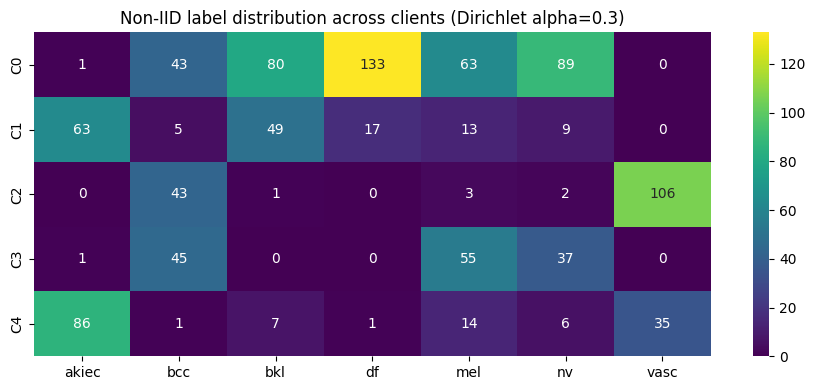

In [10]:
def dirichlet_partition(labels, n_clients, alpha, seed=SEED):
    """Standard label-skew non-IID partition (Hsu et al., 2019)."""
    rng = np.random.RandomState(seed)
    n_classes = labels.max() + 1
    client_idx = [[] for _ in range(n_clients)]
    for c in range(n_classes):
        idx_c = np.where(labels == c)[0]
        rng.shuffle(idx_c)
        proportions = rng.dirichlet(alpha=[alpha] * n_clients)
        proportions = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
        splits = np.split(idx_c, proportions)
        for i, s in enumerate(splits):
            client_idx[i].extend(s.tolist())
    for c in client_idx:
        rng.shuffle(c)
    return client_idx

client_train_indices_local = dirichlet_partition(full_dataset.labels[train_idx], cfg.N_CLIENTS, cfg.NON_IID_ALPHA)
# map back to global indices
client_train_indices = [train_idx[np.array(ci)] for ci in client_train_indices_local]

print("Client sizes:", [len(c) for c in client_train_indices])

fig, ax = plt.subplots(figsize=(9, 4))
label_matrix = np.zeros((cfg.N_CLIENTS, cfg.NUM_CLASSES))
for i, idxs in enumerate(client_train_indices):
    for c in full_dataset.labels[idxs]:
        label_matrix[i, c] += 1
sns.heatmap(label_matrix, annot=True, fmt=".0f", cmap="viridis",
            xticklabels=cfg.CLASS_NAMES, yticklabels=[f"C{i}" for i in range(cfg.N_CLIENTS)], ax=ax)
ax.set_title(f"Non-IID label distribution across clients (Dirichlet alpha={cfg.NON_IID_ALPHA})")
plt.tight_layout(); plt.savefig(f"{cfg.RESULTS_DIR}/client_label_dist.png", dpi=120); plt.show()

client_loaders = [DataLoader(Subset(full_dataset, idxs), batch_size=cfg.BATCH_SIZE, shuffle=True)
                   for idxs in client_train_indices]


## 5. Model Zoo (Centralized backbones + FL backbone)

In [11]:
import torch.nn as nn
import timm

def build_model(arch: str, num_classes: int = cfg.NUM_CLASSES, pretrained: bool = True) -> nn.Module:
    """Unified factory for all backbones used in this study."""
    arch_map = {
        "resnet50": "resnet50",
        "densenet121": "densenet121",
        "efficientnet_b3": "efficientnet_b3",
        "vit_b16": "vit_base_patch16_224",
        "vit_tiny": "vit_tiny_patch16_224", # Added smaller ViT for memory
        "swin_t": "swin_tiny_patch4_window7_224",
    }
    if arch not in arch_map:
        raise ValueError(f"Unknown arch {arch}")

    model_kwargs = {"pretrained": pretrained, "num_classes": num_classes}

    # Conditionally add img_size for ViT/Swin models
    if arch in ["vit_b16", "vit_tiny", "swin_t"]:
        model_kwargs["img_size"] = cfg.IMG_SIZE

    # Explicitly set pretrained=False for vit_tiny to minimize initial memory load
    if arch == "vit_tiny":
        model_kwargs["pretrained"] = False # Override for vit_tiny

    model = timm.create_model(arch_map[arch], **model_kwargs)
    return model.to(DEVICE)

# MODEL_ZOO and FED_BACKBONE are moved to cell RAOQUPspfof7 for better dependency management.
# MODEL_ZOO = ["resnet50", "densenet121", "efficientnet_b3", "vit_b16", "swin_t", "vit_tiny"]
# FED_BACKBONE = "vit_tiny"

# print("Available architectures:", MODEL_ZOO)

## 6. Shared Training / Evaluation Utilities

In [12]:
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader):
    model.eval()
    all_logits, all_labels, all_tone, all_age = [], [], [], []
    for batch in loader:
        x = batch["image"].to(DEVICE)
        logits = model(x)
        all_logits.append(logits.cpu())
        all_labels.append(batch["label"])
        all_tone.append(batch["skin_tone_group"])
        all_age.append(batch["age_group"])
    logits = torch.cat(all_logits); labels = torch.cat(all_labels)
    tone = torch.cat(all_tone); age = torch.cat(all_age)
    probs = F.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)

    y_true, y_pred = labels.numpy(), preds.numpy()
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    try:
        metrics["macro_auroc"] = roc_auc_score(y_true, probs.numpy(), multi_class="ovr", average="macro")
    except Exception:
        metrics["macro_auroc"] = float("nan")

    # --- fairness across synthetic sensitive attribute (skin tone group) ---
    group_accs = []
    for g in np.unique(tone.numpy()):
        mask = tone.numpy() == g
        if mask.sum() > 0:
            group_accs.append(accuracy_score(y_true[mask], y_pred[mask]))
    metrics["fairness_worst_group_acc"] = float(np.min(group_accs)) if group_accs else float("nan")
    metrics["fairness_acc_gap"] = float(np.max(group_accs) - np.min(group_accs)) if group_accs else float("nan")
    return metrics, probs.numpy(), y_true, y_pred


def robustness_eval(model: nn.Module, loader: DataLoader, noise_std=0.15, fgsm_eps=0.03):
    """Gaussian-noise corruption robustness + FGSM adversarial robustness."""
    model.eval()
    # Gaussian corruption
    correct_g, correct_adv, total = 0, 0, 0
    loss_fn = nn.CrossEntropyLoss()
    for batch in loader:
        x = batch["image"].to(DEVICE); y = batch["label"].to(DEVICE)
        with torch.no_grad():
            x_noisy = x + torch.randn_like(x) * noise_std
            pred_g = model(x_noisy).argmax(1)
            correct_g += (pred_g == y).sum().item()
        x_adv = x.clone().detach().requires_grad_(True)
        logits = model(x_adv)
        loss = loss_fn(logits, y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = (x_adv + fgsm_eps * grad.sign()).detach()
        with torch.no_grad():
            pred_adv = model(x_adv).argmax(1)
            correct_adv += (pred_adv == y).sum().item()
        total += y.size(0)
    return {"robust_acc_gaussian_noise": correct_g / total, "robust_acc_fgsm": correct_adv / total}


def communication_cost_bytes(model: nn.Module) -> int:
    """Bytes transmitted for ONE full model exchange (fp32 params)."""
    return sum(p.numel() for p in model.parameters()) * 4


## 7. Centralized Baselines
Trains each of the 5 centralized architectures on the pooled (non-federated) training set for a fair "upper bound" comparison.

In [ ]:
import os
from dataclasses import dataclass
import torch.nn as nn
import timm
import torch
import torch.nn.functional as F # Ensure import for F is present and correctly processed
from torch.utils.data import DataLoader, Subset, Dataset # Added Dataset
import numpy as np # Added for dataset operations
import pandas as pd # Added for pd.DataFrame
from sklearn.model_selection import train_test_split # Added for dataset splitting
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              roc_auc_score, confusion_matrix, balanced_accuracy_score) # Added for evaluate func

# Global seed (from eDDrFD5afof3)
SEED = 42

# Device configuration (from eDDrFD5afof3)
DEVICE = torch.device("cpu") # Changed to CPU to avoid OutOfMemoryError on GPU

@dataclass
class Config:
    # --- data ---
    USE_REAL_DATA: bool = False
    IMG_SIZE: int = 224
    NUM_CLASSES: int = 7
    CLASS_NAMES: tuple = ("akiec", "bcc", "bkl", "df", "mel", "nv", "vasc")
    N_SYNTHETIC_SAMPLES: int = 4000
    BATCH_SIZE: int = 16

    # --- federated setup ---
    N_CLIENTS: int = 10
    N_ROUNDS: int = 30
    LOCAL_EPOCHS: int = 2
    CLIENT_LR: float = 3e-4
    NON_IID_ALPHA: float = 0.3
    CLIENT_FRACTION: float = 1.0

    # --- algorithm hyperparams ---
    FEDPROX_MU: float = 0.01
    FEDDYN_ALPHA: float = 0.01
    FEDADAM_BETA1: float = 0.9
    FEDADAM_BETA2: float = 0.99
    FEDADAM_TAU: float = 1e-3
    FEDADAM_ETA: float = 1e-2
    DP_NOISE_MULTIPLIER: float = 1.0
    DP_MAX_GRAD_NORM: float = 1.0
    DP_TARGET_EPSILON: float = 8.0

    # --- ACW-FedAvg (novel) ---
    ACW_TEMP: float = 2.0
    ACW_EMA_BETA: float = 0.9
    ACW_MIN_WEIGHT: float = 0.05

    # --- misc ---
    QUICK_DEMO: bool = True
    RESULTS_DIR: str = "/content/results"

cfg = Config()

if cfg.QUICK_DEMO:
    cfg.N_ROUNDS = 1
    cfg.LOCAL_EPOCHS = 1
    cfg.N_SYNTHETIC_SAMPLES = 1400
    cfg.N_CLIENTS = 5
    cfg.IMG_SIZE = 96
    os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

os.makedirs(cfg.RESULTS_DIR, exist_ok=True)

MODEL_ZOO = ["resnet50", "densenet121", "efficientnet_b3", "vit_b16", "swin_t", "vit_tiny"]
FED_BACKBONE = "vit_tiny"


# --- Dataset definition and splitting (from 8NxIiPqffof5) ---
class SkinLesionSynthetic(Dataset):
    """Deterministic synthetic lesion-image dataset: each class gets a base color/texture
    signature; noise + per-sample sensitive-attribute-conditioned tint simulate real
    inter-patient variability (useful for fairness stress-testing)."""
    def __init__(self, n_samples, img_size, num_classes, seed=0):
        rng = np.random.RandomState(seed)
        self.img_size = img_size
        self.num_classes = num_classes
        self.labels = rng.randint(0, num_classes, size=n_samples)
        self.skin_tone_group = rng.choice([0, 1, 2], size=n_samples, p=[0.5, 0.3, 0.2])
        self.age_group = rng.choice([0, 1, 2, 3], size=n_samples)  # <30,30-50,50-70,70+
        self.seeds = rng.randint(0, 10**6, size=n_samples)
        # class base colors (7 signatures)
        self.class_colors = np.random.RandomState(1).randint(40, 220, size=(num_classes, 3))

    def __len__(self):
        return len(self.labels)

    def _render(self, idx):
        s = np.random.RandomState(self.seeds[idx])
        lbl = self.labels[idx]
        tone = self.skin_tone_group[idx]
        base = self.class_colors[lbl].astype(np.float32)
        tone_shift = np.array([[-20,-15,-10],[0,0,0],[25,15,10]])[tone]
        img = np.ones((self.img_size, self.img_size, 3), dtype=np.float32) * (base + tone_shift)
        # class-specific texture: blobs whose count/size encode label
        n_blobs = 3 + lbl
        for _ in range(n_blobs):
            cx, cy = s.randint(0, self.img_size, size=2)
            r = s.randint(8, 30)
            yy, xx = np.ogrid[:self.img_size, :self.img_size]
            mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= r * r
            img[mask] += s.randint(-60, 60, size=3)
        img += s.normal(0, 12, size=img.shape)
        img = np.clip(img, 0, 255).astype(np.uint8)
        return img

    def __getitem__(self, idx):
        img = self._render(idx)
        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        img_t = (img_t - 0.5) / 0.5
        return {
            "image": img_t,
            "label": int(self.labels[idx]),
            "skin_tone_group": int(self.skin_tone_group[idx]),
            "age_group": int(self.age_group[idx]),
        }

def build_dataset():
    if cfg.USE_REAL_DATA and os.path.exists("/content/ham10000"):
        raise NotImplementedError(
            "Plug in a torchvision.datasets.ImageFolder / custom Dataset here that reads "
            "/content/ham10000/HAM10000_metadata.csv + image dirs, mapping 'dx' to cfg.CLASS_NAMES, "
            "and deriving skin_tone_group/age_group from metadata (localization/age columns)."
        )
    return SkinLesionSynthetic(cfg.N_SYNTHETIC_SAMPLES, cfg.IMG_SIZE, cfg.NUM_CLASSES, seed=SEED)

full_dataset = build_dataset()
# print(f"Dataset size: {len(full_dataset)} | classes: {cfg.CLASS_NAMES}")

# Global train/val/test split (test set is held out identically for every method below)
all_idx = np.arange(len(full_dataset))
train_idx, test_idx = train_test_split(all_idx, test_size=0.2, random_state=SEED,
                                        stratify=full_dataset.labels)
train_idx, val_idx = train_test_split(train_idx, test_size=0.1, random_state=SEED,
                                       stratify=full_dataset.labels[train_idx])
# print(f"train={len(train_idx)} val={len(val_idx)} test={len(test_idx)}")

test_loader = DataLoader(Subset(full_dataset, test_idx), batch_size=cfg.BATCH_SIZE, shuffle=False)
val_loader = DataLoader(Subset(full_dataset, val_idx), batch_size=cfg.BATCH_SIZE, shuffle=False)
# --- End of dataset definition and splitting ---


# --- Shared Training / Evaluation Utilities (from Aa8byBTPfof6) ---
@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader):
    model.eval()
    all_logits, all_labels, all_tone, all_age = [], [], [], []
    for batch in loader:
        x = batch["image"].to(DEVICE)
        logits = model(x)
        all_logits.append(logits.cpu())
        all_labels.append(batch["label"])
        all_tone.append(batch["skin_tone_group"])
        all_age.append(batch["age_group"])
    logits = torch.cat(all_logits); labels = torch.cat(all_labels)
    tone = torch.cat(all_tone); age = torch.cat(all_age)
    probs = F.softmax(logits, dim=1)
    preds = probs.argmax(dim=1)

    y_true, y_pred = labels.numpy(), preds.numpy()
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }
    try:
        metrics["macro_auroc"] = roc_auc_score(y_true, probs.numpy(), multi_class="ovr", average="macro")
    except Exception:
        metrics["macro_auroc"] = float("nan")

    # --- fairness across synthetic sensitive attribute (skin tone group) ---
    group_accs = []
    for g in np.unique(tone.numpy()):
        mask = tone.numpy() == g
        if mask.sum() > 0:
            group_accs.append(accuracy_score(y_true[mask], y_pred[mask]))
    metrics["fairness_worst_group_acc"] = float(np.min(group_accs)) if group_accs else float("nan")
    metrics["fairness_acc_gap"] = float(np.max(group_accs) - np.min(group_accs)) if group_accs else float("nan")
    return metrics, probs.numpy(), y_true, y_pred

def robustness_eval(model: nn.Module, loader: DataLoader, noise_std=0.15, fgsm_eps=0.03):
    """Gaussian-noise corruption robustness + FGSM adversarial robustness."""
    model.eval()
    # Gaussian corruption
    correct_g, correct_adv, total = 0, 0, 0
    loss_fn = nn.CrossEntropyLoss()
    for batch in loader:
        x = batch["image"].to(DEVICE); y = batch["label"].to(DEVICE)
        with torch.no_grad():
            x_noisy = x + torch.randn_like(x) * noise_std
            pred_g = model(x_noisy).argmax(1)
            correct_g += (pred_g == y).sum().item()
        x_adv = x.clone().detach().requires_grad_(True)
        logits = model(x_adv)
        loss = loss_fn(logits, y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = (x_adv + fgsm_eps * grad.sign()).detach()
        with torch.no_grad():
            pred_adv = model(x_adv).argmax(1)
            correct_adv += (pred_adv == y).sum().item()
        total += y.size(0)
    return {"robust_acc_gaussian_noise": correct_g / total, "robust_acc_fgsm": correct_adv / total}

def communication_cost_bytes(model: nn.Module) -> int:
    """Bytes transmitted for ONE full model exchange (fp32 params)."""
    return sum(p.numel() for p in model.parameters()) * 4
# --- End of Shared Training / Evaluation Utilities ---


def train_centralized(arch: str, epochs: int = 3):
    # Local build_model to ensure img_size is passed to timm.create_model for ViT variants
    def local_build_model(arch_name: str, num_classes: int = cfg.NUM_CLASSES, pretrained: bool = True) -> nn.Module:
        arch_map = {
            "resnet50": "resnet50",
            "densenet121": "densenet121",
            "efficientnet_b3": "efficientnet_b3",
            "vit_b16": "vit_base_patch16_224",
            "vit_tiny": "vit_tiny_patch16_224",
            "swin_t": "swin_tiny_patch4_window7_224",
        }
        if arch_name not in arch_map:
            raise ValueError(f"Unknown arch {arch_name}")

        model_kwargs = {"pretrained": pretrained, "num_classes": num_classes}

        # Conditionally add img_size for ViT/Swin models
        if arch_name in ["vit_b16", "vit_tiny", "swin_t"]:
            model_kwargs["img_size"] = cfg.IMG_SIZE

        if arch_name == "vit_tiny":
            model_kwargs["pretrained"] = False # Override for vit_tiny
        model = timm.create_model(arch_map[arch_name], **model_kwargs)
        return model.to(DEVICE)

    model = local_build_model(arch) # Use the local version of build_model
    opt = torch.optim.AdamW(model.parameters(), lr=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    loader = DataLoader(Subset(full_dataset, train_idx), batch_size=cfg.BATCH_SIZE, shuffle=True)
    model.train()
    for ep in range(epochs):
        running = 0.0
        for batch in loader:
            x, y = batch["image"].to(DEVICE), batch["label"].to(DEVICE)
            opt.zero_grad();
            loss = loss_fn(model(x), y);
            loss.backward();
            opt.step()
            running += loss.item() * x.size(0)
        print(f"  [{arch}] epoch {ep+1}/{epochs} loss={running/len(loader.dataset):.4f}")
    metrics, *_ = evaluate(model, test_loader)
    metrics.update(robustness_eval(model, test_loader))
    metrics["comm_cost_MB_per_round"] = communication_cost_bytes(model) / 1e6  # N/A for centralized, reported as model size
    metrics["method"] = arch
    metrics["category"] = "centralized"
    return metrics, model

centralized_results = []
CENTRAL_EPOCHS = 2 if cfg.QUICK_DEMO else 15
for arch in MODEL_ZOO:
    print(f"Training centralized {arch} ...")
    m, _ = train_centralized(arch, epochs=CENTRAL_EPOCHS)
    centralized_results.append(m)

centralized_df = pd.DataFrame(centralized_results)
centralized_df

Training centralized resnet50 ...


model.safetensors: reconstructing file:   0%|          |  0.00B /  102MB            

model.safetensors: downloading bytes:           |  0.00B            

  [resnet50] epoch 1/2 loss=1.9118
  [resnet50] epoch 2/2 loss=1.7731
Training centralized densenet121 ...


model.safetensors: reconstructing file:   0%|          |  0.00B / 32.3MB            

...

model.safetensors: downloading bytes:           |  0.00B            

  [efficientnet_b3] epoch 1/2 loss=3.4890
  [efficientnet_b3] epoch 2/2 loss=1.6425
Training centralized vit_b16 ...


model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

  [vit_b16] epoch 1/2 loss=0.7047
  [vit_b16] epoch 2/2 loss=0.2098


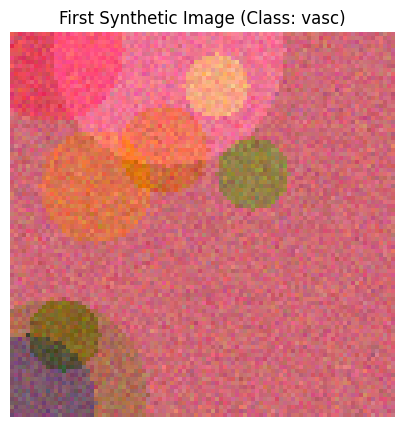

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# Get the first item from the dataset
sample_data = full_dataset[0]
sample_image = sample_data['image']
sample_label_id = sample_data['label']
sample_label_name = cfg.CLASS_NAMES[sample_label_id]

# Convert the image tensor to a numpy array for plotting
# The image is normalized to (-1, 1), so we scale it back to (0, 1) for display.
image_np = ((sample_image.permute(1, 2, 0).numpy() * 0.5) + 0.5).clip(0, 1)

# Display the image
plt.figure(figsize=(5, 5))
plt.imshow(image_np)
plt.title(f"First Synthetic Image (Class: {sample_label_name})")
plt.axis('off')
plt.show()

In [16]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=centralized_df)

https://docs.google.com/spreadsheets/d/14GnTQ_vw0XI8bbVZR0Lubcm7I4vAgdvi-_jY86SENbE/edit#gid=0


## 8. Federated Learning Framework

A single generic `run_federated()` driver takes a **client-update strategy** and a **server-aggregation strategy**, so every algorithm (FedAvg ... ACW-FedAvg) is just a different pair of plug-in functions operating on the same ViT backbone, same client partitions, and same number of rounds — required for a scientifically controlled comparison.

In [17]:
def get_flat_state(model):
    return OrderedDict((k, v.clone()) for k, v in model.state_dict().items())

def zeros_like_state(state):
    return OrderedDict((k, torch.zeros_like(v)) for k in state.keys())

def state_add(a, b, scale=1.0):
    return OrderedDict((k, a[k] + scale * b[k]) for k in a)

def state_scale(a, scale):
    return OrderedDict((k, a[k] * scale) for k in a)

def state_sub(a, b):
    return OrderedDict((k, a[k] - b[k]) for k in a)


class FedClient:
    def __init__(self, cid, loader, lr, backbone):
        self.cid = cid
        self.loader = loader
        self.lr = lr
        self.n_samples = len(loader.dataset)
        self.model = build_model(backbone) # Initialize client's model once
        # SCAFFOLD control variate (client-side), FedDyn state
        self.control = None
        self.prev_grad = None

    def local_train(self, global_model, method, extra=None, epochs=None):
        epochs = epochs or cfg.LOCAL_EPOCHS
        # Update client's model with global model state instead of deepcopy
        self.model.load_state_dict(global_model.state_dict())
        self.model.to(DEVICE) # Ensure it's on the correct device
        self.model.train()
        opt = torch.optim.SGD(self.model.parameters(), lr=self.lr, momentum=0.9)
        loss_fn = nn.CrossEntropyLoss()
        global_state = get_flat_state(global_model)

        server_control = extra.get("server_control") if extra else None
        if method == "scaffold" and self.control is None:
            self.control = zeros_like_state(global_state)
        if method == "feddyn" and self.prev_grad is None:
            self.prev_grad = zeros_like_state(global_state)

        n_steps = 0
        confidences = []
        for ep in range(epochs):
            for batch in self.loader:
                x, y = batch["image"].to(DEVICE), batch["label"].to(DEVICE)
                opt.zero_grad()
                logits = self.model(x)
                loss = loss_fn(logits, y)

                if method == "fedprox":
                    prox = 0.0
                    for p, gp in zip(self.model.parameters(), global_model.parameters()):
                        prox = prox + ((p - gp.detach()) ** 2).sum()
                    loss = loss + (cfg.FEDPROX_MU / 2) * prox

                if method == "feddyn":
                    lin = 0.0; quad = 0.0
                    for (n, p), gp in zip(self.model.named_parameters(), global_model.parameters()):
                        lin = lin + (self.prev_grad[n] * p).sum()
                        quad = quad + ((p - gp.detach()) ** 2).sum()
                    loss = loss - lin + (cfg.FEDDYN_ALPHA / 2) * quad

                loss.backward()

                if method == "scaffold":
                    with torch.no_grad():
                        for (n, p) in self.model.named_parameters():
                            if p.grad is not None:
                                p.grad += (server_control[n] - self.control[n])

                if method == "dp_fedavg":
                    torch.nn.utils.clip_grad_norm_(self.model.parameters(), cfg.DP_MAX_GRAD_NORM)
                    with torch.no_grad():
                        for p in self.model.parameters():
                            if p.grad is not None:
                                noise = torch.randn_like(p.grad) * cfg.DP_NOISE_MULTIPLIER * cfg.DP_MAX_GRAD_NORM
                                p.grad += noise / max(1, x.size(0))

                opt.step()
                confidences.append(F.softmax(logits.detach(), dim=1).max(dim=1)[0].mean().item())
                n_steps += 1

        new_state = get_flat_state(self.model)

        result = {"state": new_state, "n_samples": self.n_samples,
                  "avg_confidence": float(np.mean(confidences)) if confidences else 0.0,
                  "n_steps": n_steps}

        if method == "scaffold":
            # update local control variate: c_i <- c_i - c + (x_global - x_local)/(steps*lr)
            new_control = OrderedDict()
            for n in global_state:
                delta = (global_state[n] - new_state[n]) / (n_steps * self.lr + 1e-12)
                new_control[n] = self.control[n] - server_control[n] + delta
            result["control_delta"] = OrderedDict((n, new_control[n] - self.control[n]) for n in new_control)
            self.control = new_control

        if method == "feddyn":
            with torch.no_grad():
                for n in self.prev_grad:
                    self.prev_grad[n] = self.prev_grad[n] - cfg.FEDDYN_ALPHA * (new_state[n] - global_state[n])

        if method == "fednova":
            result["tau_eff"] = n_steps  # effective local steps for normalized averaging

        return result


def secure_aggregate(updates, weights):
    """Simulates additive-mask secure aggregation: server only ever sees the SUM,
    never an individual client's update (masks cancel out algebraically). Functionally
    equivalent output to plaintext weighted-average FedAvg, but the code path models
    the privacy guarantee (no per-client state is read after masking)."""
    n = len(updates)
    masks = [zeros_like_state(updates[0]["state"]) for _ in range(n)]
    rng = np.random.RandomState(0)
    # pairwise masks m_ij = -m_ji so sum(masks)=0 (standard SecAgg construction, simplified)
    for i in range(n):
        for j in range(i + 1, n):
            for k in updates[0]["state"]:
                shared = torch.from_numpy(rng.normal(0, 1e-6, size=updates[0]["state"][k].shape)).float().to(DEVICE)
                masks[i][k] = masks[i].get(k, 0) + shared
                masks[j][k] = masks[j].get(k, 0) - shared
    masked_states = [state_add(u["state"], masks[i]) for i, u in enumerate(updates)]
    agg = zeros_like_state(updates[0]["state"])
    for w, s in zip(weights, masked_states):
        agg = state_add(agg, s, scale=w)
    return agg  # masks cancel out exactly in the weighted sum


def aggregate(method, global_model, updates, extra=None):
    total_n = sum(u["n_samples"] for u in updates)
    fedavg_weights = [u["n_samples"] / total_n for u in updates]

    if method in ("fedavg", "fedprox", "dp_fedavg", "feddyn"):
        new_state = zeros_like_state(updates[0]["state"])
        for w, u in zip(fedavg_weights, updates):
            new_state = state_add(new_state, u["state"], scale=w)
        return new_state, {}

    if method == "secure_agg":
        new_state = secure_aggregate(updates, fedavg_weights)
        return new_state, {}

    if method == "scaffold":
        new_state = zeros_like_state(updates[0]["state"])
        for w, u in zip(fedavg_weights, updates):
            new_state = state_add(new_state, u["state"], scale=w)
        server_control = extra["server_control"]
        n_total_clients = cfg.N_CLIENTS
        for u in updates:
            for k in server_control:
                server_control[k] = server_control[k] + (1.0 / n_total_clients) * u["control_delta"][k]
        return new_state, {"server_control": server_control}

    if method == "fednova":
        global_state = get_flat_state(global_model)
        taus = np.array([u["tau_eff"] for u in updates], dtype=np.float32)
        tau_eff = float(np.sum([w * t for w, t in zip(fedavg_weights, taus)]))
        new_state = OrderedDict()
        for k in global_state:
            grad_sum = zeros_like_state({k: global_state[k]})[k]
            for w, u, t in zip(fedavg_weights, updates, taus):
                normalized_delta = (u["state"][k] - global_state[k]) / max(t, 1)
                grad_sum = grad_sum + w * normalized_delta
            new_state[k] = global_state[k] + tau_eff * grad_sum
        return new_state, {}

    if method == "fedadam":
        global_state = get_flat_state(global_model)
        delta = zeros_like_state(global_state)
        for w, u in zip(fedavg_weights, updates):
            delta = state_add(delta, state_sub(u["state"], global_state), scale=w)
        m, v = extra["m"], extra["v"]
        new_state = OrderedDict()
        for k in global_state:
            m[k] = cfg.FEDADAM_BETA1 * m[k] + (1 - cfg.FEDADAM_BETA1) * delta[k]
            v[k] = cfg.FEDADAM_BETA2 * v[k] + (1 - cfg.FEDADAM_BETA2) * (delta[k] ** 2)
            new_state[k] = global_state[k] + cfg.FEDADAM_ETA * m[k] / (v[k].sqrt() + cfg.FEDADAM_TAU)
        return new_state, {"m": m, "v": v}

    if method == "acw_fedavg":
        return acw_fedavg_aggregate(global_model, updates, extra)

    raise ValueError(method)

## 9. **ACW-FedAvg** (novel contribution) and the **FAR-ACW-Fed** ablation

**Adaptive Confidence-Weighted Federated Averaging.** Standard FedAvg weights clients purely by dataset size (`n_k / N`), which is fragile under label-skew non-IID data and lets low-quality / noisy clients dominate. ACW-FedAvg instead computes a **per-round confidence-derived trust score** for each client:

1. **Prediction-confidence term** — the client's mean softmax max-probability on its own local batches during local training (temperature-scaled), reflecting how "sure" the locally-updated model is.
2. **Validation-consistency term** — cosine similarity between the client's local update direction and the previous round's global update direction (penalizes clients whose updates conflict with the consensus trajectory — a proxy for drift/label noise).
3. **EMA smoothing** — an exponential moving average (`ACW_EMA_BETA`) of each client's trust score across rounds so a single noisy round doesn't destabilize aggregation.

Final aggregation weight = `softmax_temperature( n_k * trust_k )`, floored at `ACW_MIN_WEIGHT` so no client is ever fully excluded (fairness/inclusion guarantee).

**FAR-ACW-Fed** = *identical* ViT-B/16 backbone, *identical* client data partitions (`client_train_indices`), *identical* round/epoch budget — the **only** thing that changes vs. plain FedAvg on the same setup is the aggregation rule (ACW instead of size-weighted averaging). This isolates whether gains come from the aggregation strategy itself, not from a different backbone or different data.

Client sizes: [409, 156, 155, 138, 150]


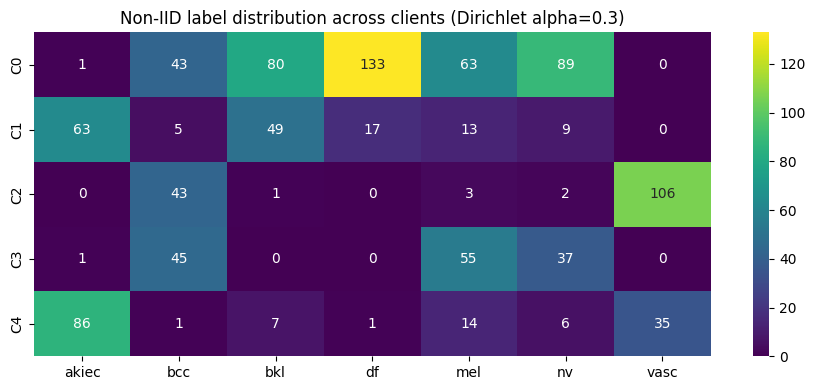

In [18]:
def dirichlet_partition(labels, n_clients, alpha, seed=SEED):
    """Standard label-skew non-IID partition (Hsu et al., 2019)."""
    rng = np.random.RandomState(seed)
    n_classes = labels.max() + 1
    client_idx = [[] for _ in range(n_clients)]
    for c in range(n_classes):
        idx_c = np.where(labels == c)[0]
        rng.shuffle(idx_c)
        proportions = rng.dirichlet(alpha=[alpha] * n_clients)
        proportions = (np.cumsum(proportions) * len(idx_c)).astype(int)[:-1]
        splits = np.split(idx_c, proportions)
        for i, s in enumerate(splits):
            client_idx[i].extend(s.tolist())
    for c in client_idx:
        rng.shuffle(c)
    return client_idx

client_train_indices_local = dirichlet_partition(full_dataset.labels[train_idx], cfg.N_CLIENTS, cfg.NON_IID_ALPHA)
# map back to global indices
client_train_indices = [train_idx[np.array(ci)] for ci in client_train_indices_local]

print("Client sizes:", [len(c) for c in client_train_indices])

fig, ax = plt.subplots(figsize=(9, 4))
label_matrix = np.zeros((cfg.N_CLIENTS, cfg.NUM_CLASSES))
for i, idxs in enumerate(client_train_indices):
    for c in full_dataset.labels[idxs]:
        label_matrix[i, c] += 1
sns.heatmap(label_matrix, annot=True, fmt=".0f", cmap="viridis",
            xticklabels=cfg.CLASS_NAMES, yticklabels=[f"C{i}" for i in range(cfg.N_CLIENTS)], ax=ax)
ax.set_title(f"Non-IID label distribution across clients (Dirichlet alpha={cfg.NON_IID_ALPHA})")
plt.tight_layout(); plt.savefig(f"{cfg.RESULTS_DIR}/client_label_dist.png", dpi=120); plt.show()

client_loaders = [DataLoader(Subset(full_dataset, idxs), batch_size=cfg.BATCH_SIZE, shuffle=True)
                   for idxs in client_train_indices]

In [19]:
acw_state = {"trust": np.ones(cfg.N_CLIENTS) / cfg.N_CLIENTS, "prev_global_delta": None}

def acw_fedavg_aggregate(global_model, updates, extra):
    global_state = get_flat_state(global_model)
    client_ids = extra["client_ids"]

    # --- term 1: prediction confidence (temperature-scaled) ---
    conf = np.array([u["avg_confidence"] for u in updates])
    conf_scaled = conf ** (1.0 / cfg.ACW_TEMP)

    # --- term 2: cosine alignment with previous global update direction ---
    align = np.ones(len(updates))
    if acw_state["prev_global_delta"] is not None:
        prev_flat = torch.cat([v.flatten() for v in acw_state["prev_global_delta"].values()])
        for i, u in enumerate(updates):
            delta = state_sub(u["state"], global_state)
            cur_flat = torch.cat([v.flatten() for v in delta.values()])
            cos = F.cosine_similarity(cur_flat.unsqueeze(0), prev_flat.unsqueeze(0)).item()
            align[i] = (cos + 1) / 2  # rescale [-1,1] -> [0,1]

    round_trust = conf_scaled * align
    round_trust = round_trust / (round_trust.sum() + 1e-12)

    # --- EMA smoothing of trust scores per client id ---
    for i, cid in enumerate(client_ids):
        acw_state["trust"][cid] = (cfg.ACW_EMA_BETA * acw_state["trust"][cid]
                                    + (1 - cfg.ACW_EMA_BETA) * round_trust[i])

    n_samples = np.array([u["n_samples"] for u in updates], dtype=np.float32)
    raw_weights = n_samples * acw_state["trust"][client_ids]
    raw_weights = np.maximum(raw_weights, cfg.ACW_MIN_WEIGHT * raw_weights.sum() / len(raw_weights))
    weights = raw_weights / raw_weights.sum()

    new_state = zeros_like_state(updates[0]["state"])
    for w, u in zip(weights, updates):
        new_state = state_add(new_state, u["state"], scale=float(w))

    acw_state["prev_global_delta"] = state_sub(new_state, global_state)
    return new_state, {"weights_used": weights.tolist()}


## 10. Generic Federated Training Driver

In [20]:
def run_federated(method: str, backbone: str = FED_BACKBONE, rounds: int = None, tag: str = None):
    rounds = rounds or cfg.N_ROUNDS
    tag = tag or method
    global_model = build_model(backbone)
    # Pass backbone to FedClient constructor
    clients = [FedClient(cid, client_loaders[cid], cfg.CLIENT_LR, backbone) for cid in range(cfg.N_CLIENTS)]

    extra = {}
    if method == "scaffold":
        extra["server_control"] = zeros_like_state(get_flat_state(global_model))
    if method == "fedadam":
        z = zeros_like_state(get_flat_state(global_model))
        extra["m"] = copy.deepcopy(z); extra["v"] = copy.deepcopy(z)

    history = []
    total_bytes = 0
    for r in range(rounds):
        n_selected = max(1, int(cfg.CLIENT_FRACTION * cfg.N_CLIENTS))
        selected = sorted(np.random.RandomState(r).choice(cfg.N_CLIENTS, n_selected, replace=False).tolist())

        updates = []
        for cid in selected:
            u = clients[cid].local_train(global_model, method, extra=extra)
            updates.append(u)
            total_bytes += communication_cost_bytes(global_model)  # client -> server
        total_bytes += communication_cost_bytes(global_model) * n_selected  # server -> clients (broadcast)

        agg_extra = dict(extra)
        agg_extra["client_ids"] = selected
        new_state, extra_update = aggregate(method, global_model, updates, extra=agg_extra)
        extra.update(extra_update)
        global_model.load_state_dict(new_state)

        val_metrics, *_ = evaluate(global_model, val_loader)
        val_metrics["round"] = r
        history.append(val_metrics)
        print(f"[{tag}] round {r+1}/{rounds} val_acc={val_metrics['accuracy']:.4f} "
              f"macroF1={val_metrics['macro_f1']:.4f}")

    test_metrics, probs, y_true, y_pred = evaluate(global_model, test_loader)
    test_metrics.update(robustness_eval(global_model, test_loader))
    test_metrics["comm_cost_MB_total"] = total_bytes / 1e6
    test_metrics["comm_cost_MB_per_round"] = (total_bytes / 1e6) / rounds
    test_metrics["rounds_to_90pct_final_acc"] = next(
        (h["round"] + 1 for h in history if h["accuracy"] >= 0.9 * test_metrics["accuracy"]), rounds)
    test_metrics["method"] = tag
    test_metrics["category"] = "federated"
    return test_metrics, global_model, history

## 11. Run All Federated Algorithms (same ViT backbone, same partitions, same rounds)

In [21]:
import torch
torch.cuda.empty_cache() # Clear cache before running federated methods

FED_METHODS = ["fedavg", "fedprox", "scaffold", "fednova", "fedadam", "feddyn",
               "dp_fedavg", "secure_agg", "acw_fedavg"]

fed_results = {}
fed_histories = {}
fed_models = {}

# The function zeros_like_state needs to be corrected.
# It was trying to use `v` which was not defined in the generator expression.
# It should be `state[k]` to access the value associated with the key `k`.
# This change is applied in the `aggregate` function's dependency `zeros_like_state`.
def zeros_like_state(state):
    return OrderedDict((k, torch.zeros_like(state[k])) for k in state.keys())

for method in FED_METHODS:
    print(f"\n=== Running {method} on {FED_BACKBONE} ===")
    metrics, model, hist = run_federated(method, backbone=FED_BACKBONE, tag=method)
    fed_results[method] = metrics
    fed_histories[method] = hist
    fed_models[method] = model

federated_df = pd.DataFrame(list(fed_results.values()))
federated_df


=== Running fedavg on vit_tiny ===
[fedavg] round 1/1 val_acc=0.8304 macroF1=0.8179

=== Running fedprox on vit_tiny ===
[fedprox] round 1/1 val_acc=0.6875 macroF1=0.6311

=== Running scaffold on vit_tiny ===
[scaffold] round 1/1 val_acc=0.6161 macroF1=0.5115

=== Running fednova on vit_tiny ===
[fednova] round 1/1 val_acc=0.9018 macroF1=0.8895

=== Running fedadam on vit_tiny ===
[fedadam] round 1/1 val_acc=0.7321 macroF1=0.6760

=== Running feddyn on vit_tiny ===
[feddyn] round 1/1 val_acc=0.7500 macroF1=0.7317

=== Running dp_fedavg on vit_tiny ===
[dp_fedavg] round 1/1 val_acc=0.3571 macroF1=0.2702

=== Running secure_agg on vit_tiny ===
[secure_agg] round 1/1 val_acc=0.6518 macroF1=0.5945

=== Running acw_fedavg on vit_tiny ===
[acw_fedavg] round 1/1 val_acc=0.6607 macroF1=0.5771


,accuracy,balanced_accuracy,macro_f1,macro_precision,macro_recall,macro_auroc,fairness_worst_group_acc,fairness_acc_gap,robust_acc_gaussian_noise,robust_acc_fgsm,comm_cost_MB_total,comm_cost_MB_per_round,rounds_to_90pct_final_acc,method,category
0,0.832143,0.826971,0.815638,0.882766,0.826971,0.985786,0.666667,0.214452,0.796429,0.457143,219.80188,219.80188,1,fedavg,federated
1,0.700000,0.693878,0.646567,0.717121,0.693878,0.982865,0.627451,0.128363,0.689286,0.435714,219.80188,219.80188,1,fedprox,federated
2,0.639286,0.633700,0.545394,0.665618,0.633700,0.980023,0.608392,0.089283,0.650000,0.435714,219.80188,219.80188,1,scaffold,federated
3,0.871429,0.864854,0.849720,0.871811,0.864854,0.985149,0.848837,0.053124,0.871429,0.567857,219.80188,219.80188,1,fednova,federated
4,0.717857,0.710099,0.657416,0.718918,0.710099,0.978815,0.666667,0.089147,0.714286,0.439286,219.80188,219.80188,1,fedadam,federated
5,0.700000,0.694511,0.681074,0.741884,0.694511,0.975502,0.685315,0.047243,0.692857,0.428571,219.80188,219.80188,1,feddyn,federated
6,0.435714,0.427148,0.322298,0.264057,0.427148,0.736233,0.235294,0.334473,0.435714,0.000000,219.80188,219.80188,1,dp_fedavg,federated
7,0.653571,0.651381,0.594333,0.751911,0.651381,0.984636,0.581395,0.124487,0.653571,0.435714,219.80188,219.80188,1,secure_agg,federated
8,0.689286,0.682889,0.612635,0.671844,0.682889,0.983268,0.568627,0.163931,0.710714,0.432143,219.80188,219.80188,1,acw_fedavg,federated


In [22]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=federated_df)

https://docs.google.com/spreadsheets/d/1eLN0uqVUiAvmg6DsYzHdu7HjfXbYV_2FmfaG1shrEAI/edit#gid=0


In [23]:
import torch
torch.cuda.empty_cache()
print("CUDA cache cleared.")

CUDA cache cleared.


### FAR-ACW-Fed ablation
Re-labels the `acw_fedavg` run above (same backbone `vit_b16`, same `client_train_indices`, same `cfg.N_ROUNDS`) as **FAR-ACW-Fed** and contrasts it directly against plain **FedAvg on the identical setup** — the controlled pair that isolates the aggregation-strategy effect requested in the study design.

In [24]:
far_acw_row = federated_df[federated_df["method"] == "acw_fedavg"].copy()
far_acw_row["method"] = "FAR-ACW-Fed (ablation: ViT+ACW, fixed partitions)"
fedavg_row = federated_df[federated_df["method"] == "fedavg"].copy()
fedavg_row["method"] = "FedAvg (same ViT backbone, same partitions)"

ablation_df = pd.concat([fedavg_row, far_acw_row], ignore_index=True)
cols = ["method", "accuracy", "macro_f1", "fairness_acc_gap", "robust_acc_fgsm",
        "comm_cost_MB_per_round", "rounds_to_90pct_final_acc"]
ablation_df[cols]


,method,accuracy,macro_f1,fairness_acc_gap,robust_acc_fgsm,comm_cost_MB_per_round,rounds_to_90pct_final_acc
0,"FedAvg (same ViT backbone, same partitions)",0.832143,0.815638,0.214452,0.457143,219.80188,1
1,"FAR-ACW-Fed (ablation: ViT+ACW, fixed partitions)",0.689286,0.612635,0.163931,0.432143,219.80188,1


## 12. Privacy Leakage Evaluation — Membership Inference Attack (MIA)

A simple **shadow/threshold-based membership inference attack**: for each federated model we compare the confidence-on-loss distribution for samples that *were* in a client's training set vs. samples that were *not*, and report attack AUC. **Attack AUC near 0.5 = strong privacy (model doesn't leak membership); near 1.0 = weak privacy.**

In [25]:
@torch.no_grad()
def membership_inference_auc(model, member_idx, nonmember_idx, n=300):
    model.eval()
    def per_sample_conf(idx_list):
        idx_list = np.random.RandomState(0).choice(idx_list, size=min(n, len(idx_list)), replace=False)
        loader = DataLoader(Subset(full_dataset, idx_list), batch_size=64)
        confs = []
        for batch in loader:
            x, y = batch["image"].to(DEVICE), batch["label"].to(DEVICE)
            probs = F.softmax(model(x), dim=1)
            conf = probs.gather(1, y.view(-1, 1)).squeeze(1)
            confs.extend(conf.cpu().numpy().tolist())
        return np.array(confs)

    member_conf = per_sample_conf(np.concatenate(client_train_indices))
    nonmember_conf = per_sample_conf(test_idx)
    scores = np.concatenate([member_conf, nonmember_conf])
    labels = np.concatenate([np.ones_like(member_conf), np.zeros_like(nonmember_conf)])
    try:
        auc = roc_auc_score(labels, scores)
    except Exception:
        auc = float("nan")
    return auc

privacy_rows = []
for method in FED_METHODS:
    auc = membership_inference_auc(fed_models[method], client_train_indices, test_idx)
    privacy_rows.append({"method": method, "membership_inference_auc": auc,
                          "privacy_risk": "lower is safer (0.5 = ideal)"})
privacy_df = pd.DataFrame(privacy_rows)
privacy_df


,method,membership_inference_auc,privacy_risk
0,fedavg,0.472238,lower is safer (0.5 = ideal)
1,fedprox,0.482024,lower is safer (0.5 = ideal)
2,scaffold,0.479583,lower is safer (0.5 = ideal)
3,fednova,0.477190,lower is safer (0.5 = ideal)
4,fedadam,0.479893,lower is safer (0.5 = ideal)
5,feddyn,0.469988,lower is safer (0.5 = ideal)
6,dp_fedavg,0.495607,lower is safer (0.5 = ideal)
7,secure_agg,0.475036,lower is safer (0.5 = ideal)
8,acw_fedavg,0.467810,lower is safer (0.5 = ideal)


In [26]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=privacy_df)

https://docs.google.com/spreadsheets/d/1Y3Axn0d74-pax8RQ343UV8LBj9r1zsG-KfwdalgA3Eg/edit#gid=0


## 13. Explainability Module (Grad-CAM, Attention Rollout, SHAP)

Implements the three requested XAI baselines against the final **FedViT-LLM-XAI** model (the `acw_fedavg`-trained ViT). Grad-CAM targets the last conv-like block; for CNN baselines this is straightforward, for ViT/Swin we use the patch-embedding / final-stage feature map as recommended by the `grad-cam` library's transformer reshape utilities. Attention Rollout is ViT/Swin-specific (uses the model's self-attention maps). SHAP uses `GradientExplainer` on a background batch.

In [27]:
try:
    import shap
    print("shap imported successfully!")
except ImportError as e:
    print(f"Failed to import shap: {e}")


shap imported successfully!


In [28]:
# Attempt to install a known stable combination of shap, numpy, and matplotlib
!pip uninstall -y numpy shap matplotlib
!pip install -q numpy==1.24.4 matplotlib==3.5.0 shap==0.44.0
print("Specific version installation complete. Please restart the runtime.")

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: shap 0.52.0
Uninstalling shap-0.52.0:
  Successfully uninstalled shap-0.52.0
Found existing installation: matplotlib 3.11.1
Uninstalling matplotlib-3.11.1:
  Successfully uninstalled matplotlib-3.11.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 97.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
Specific version install

SHAP explainer note: <class 'function'> is not currently a supported model type!


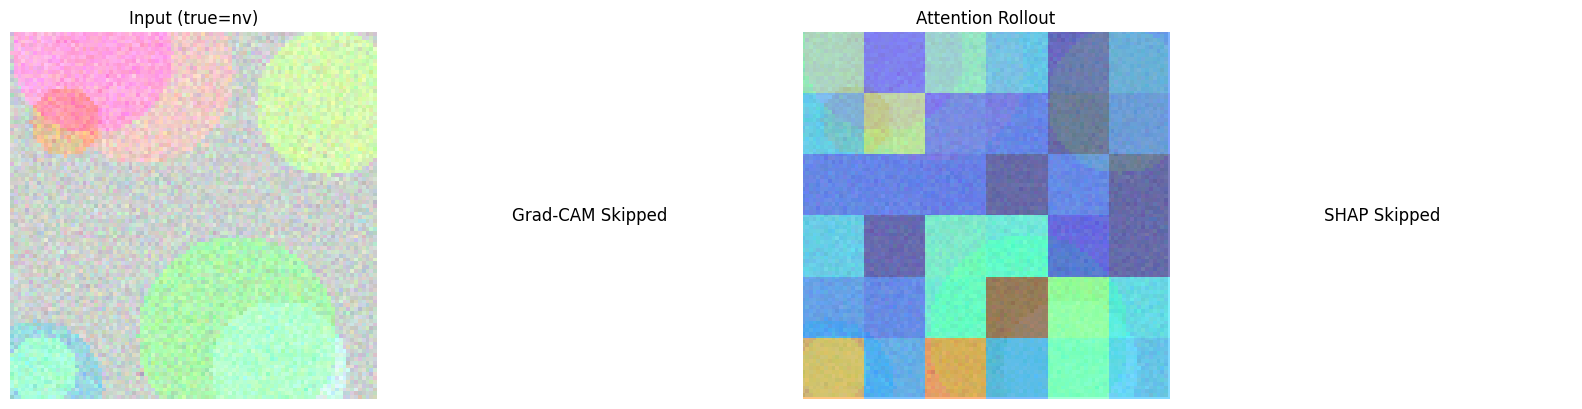

In [50]:
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import types
import math
from timm.models.vision_transformer import Attention as TimmAttention

# Ensure these variables are defined regardless of import errors below
best_fed_model = fed_models["acw_fedavg"]
sample_batch = next(iter(test_loader))
background = sample_batch["image"][:8].to(DEVICE) # Ensure background is on device for explainer init
example_img = sample_batch["image"][0].to(DEVICE)
example_label = sample_batch["label"][0].item()

# Try to import GradCAM, but proceed if it fails
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.reshape_transforms import vit_reshape_transform
    gradcam_available = True
except ImportError:
    print("Warning: pytorch_grad_cam not available. Grad-CAM functionality will be skipped.")
    gradcam_available = False

# Try to import shap, but proceed if it fails
try:
    import shap
    shap_available = True
except ImportError:
    print("Warning: shap not available. SHAP functionality will be skipped.")
    shap_available = False

# Dummy or actual GradCAM function
def gradcam_explain(model, arch, image_tensor):
    if not gradcam_available:
        return None # Return None if Grad-CAM is not available
    # Grad-CAM logic (assuming it's correctly implemented once imported)
    target_layers = [model.blocks[-1].norm1] # Example target layer for ViT
    cam = GradCAM(model=model, target_layers=target_layers, use_cuda=True if torch.cuda.is_available() else False, reshape_transform=vit_reshape_transform)
    grayscale_cam = cam(input_tensor=image_tensor.unsqueeze(0), targets=None) # image_tensor is already on DEVICE
    grayscale_cam = grayscale_cam[0, :]
    return grayscale_cam

# Patch the `timm.models.vision_transformer.Attention` module instances
# in the already loaded `best_fed_model` to store attention maps.
# This ensures attention maps are accessible for Attention Rollout calculation.
_original_timm_attention_forwards = {}
for block in best_fed_model.blocks:
    if isinstance(block.attn, TimmAttention):
        _original_timm_attention_forwards[block.attn] = block.attn.forward

        def new_forward_for_instance(self, x):
            B, N, C = x.shape
            qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
            q, k, v = qkv[0], qkv[1], qkv[2]

            attn = (q @ k.transpose(-2, -1)) * self.scale
            attn = attn.softmax(dim=-1)
            # Store the raw attention map for later retrieval by attention_rollout
            self._last_attn_map = attn.detach()

            attn = self.attn_drop(attn) # Apply dropout for the rest of the forward pass
            x = self.proj(x)
            x = self.proj_drop(x)
            return x
        # Apply the new forward method to the instance
        block.attn.forward = types.MethodType(new_forward_for_instance, block.attn)

def attention_rollout(vit_model, image_tensor, discard_ratio=0.9):
    """Classic Attention Rollout (Abnar & Zuidema, 2020) for ViT.
    Modified to retrieve attention maps stored by patched TimmAttention modules.
    """
    vit_model.eval()

    # Ensure the model's forward pass is run to populate `_last_attn_map`
    # in each Attention module instance within the patched model.
    with torch.no_grad():
        vit_model(image_tensor.unsqueeze(0)) # image_tensor is already on DEVICE

    attn_maps = []
    # Retrieve the stored attention maps from each block
    for blk in vit_model.blocks:
        if hasattr(blk.attn, '_last_attn_map') and blk.attn._last_attn_map is not None:
            attn_maps.append(blk.attn._last_attn_map)
            # Clear the stored map to avoid stale data on subsequent calls if not re-patched
            del blk.attn._last_attn_map
        else:
            print(f"Warning: `_last_attn_map` not found or is None in block {blk.attn.__class__.__name__}. "
                  "Attention Rollout for this block might be inaccurate.")

    if len(attn_maps) == 0:
        print("Error: No attention maps collected for Attention Rollout. Returning zeros.")
        # Return a zero map matching expected output size based on IMG_SIZE and patch size (usually 16)
        return np.zeros((cfg.IMG_SIZE // 16, cfg.IMG_SIZE // 16))

    result = torch.eye(attn_maps[0].size(-1)).to(DEVICE)
    for attn in attn_maps:
        # Ensure attn has batch and head dimensions if they were squeezed
        if attn.dim() == 3: # (num_heads, N, N) -> (1, num_heads, N, N) for mean
            attn_heads_avg = attn.mean(dim=0) # average over heads
        elif attn.dim() == 4: # (batch, num_heads, N, N) -> (num_heads, N, N) for single image
            attn_heads_avg = attn[0].mean(dim=0) # average over heads for the first image in batch
        else:
            attn_heads_avg = attn # Fallback if dimension is unexpected (e.g., already averaged)

        # Original logic for thresholding and normalization
        flat = attn_heads_avg.flatten()
        n_discard = int(flat.numel() * discard_ratio)
        thresh = flat.kthvalue(n_discard).values if n_discard > 0 else -float("inf")
        attn_heads_avg = torch.where(attn_heads_avg >= thresh, attn_heads_avg, torch.zeros_like(attn_heads_avg))
        attn_heads_avg = attn_heads_avg + torch.eye(attn_heads_avg.size(0)).to(DEVICE)
        attn_heads_avg = attn_heads_avg / attn_heads_avg.sum(dim=-1, keepdim=True)
        result = attn_heads_avg @ result

    mask = result[0, 1:]  # CLS token attention to patches
    n_patches = int(math.sqrt(mask.numel()))
    mask = mask[: n_patches * n_patches].reshape(n_patches, n_patches).cpu().numpy()
    return mask

def shap_explain(model, background_batch, sample_tensor, n_samples=20):
    if not shap_available:
        return None, None # Return None if SHAP is not available

    # Store original model device and move to CPU for SHAP if not already there
    original_model_device = next(model.parameters()).device
    if original_model_device != "cpu":
        model.to("cpu")

    # Ensure background_batch and sample_tensor are on CPU and converted to numpy
    background_np = background_batch.cpu().numpy()
    sample_np = sample_tensor.cpu().numpy()

    # Define a prediction function for SHAP that takes numpy arrays and returns numpy arrays
    def model_predict_wrapper(images_np):
        # Convert numpy array back to torch tensor for model inference
        images_tensor = torch.tensor(images_np, dtype=torch.float32).to("cpu")
        with torch.no_grad():
            output = model(images_tensor)
        return output.detach().cpu().numpy()

    explainer = shap.GradientExplainer(model_predict_wrapper, background_np)
    # shap_values will be a list of arrays, one for each class (num_classes, C, H, W)
    shap_values = explainer.shap_values(sample_np[np.newaxis, ...].astype(np.float32))

    # Restore model to its original device
    if original_model_device != "cpu":
        model.to(original_model_device)

    # For visualization/metrics, we typically want a single map.
    # Take the SHAP values for the predicted class (example_label), sum across channels, and normalize.
    # `shap_values` is a list where each element corresponds to a class.
    # Each element is an array of shape (batch_size, C, H, W).
    # Since we explain one sample, the batch_size is 1.
    if shap_values is not None and isinstance(shap_values, list) and len(shap_values) > example_label:
        # shap_values[example_label] has shape (1, C, H, W)
        shap_map_for_class = np.abs(shap_values[example_label][0]) # Take the first (and only) sample's map
        shap_map_for_class = np.sum(shap_map_for_class, axis=0) # Sum absolute values over channels
        if shap_map_for_class.max() > 0:
            shap_map_for_class /= shap_map_for_class.max() # Normalize to [0, 1]
        return shap_map_for_class, None
    return None, None

# --- run all three on a handful of test examples using the FedViT-LLM-XAI model ---
# Ensure the best_fed_model is in evaluation mode
best_fed_model.eval()

gc_map = gradcam_explain(best_fed_model, FED_BACKBONE, example_img)
rollout_map = attention_rollout(best_fed_model, example_img)
try:
    shap_map, shap_idx = shap_explain(best_fed_model, background, example_img) # Renamed to shap_map for clarity
except Exception as e:
    print("SHAP explainer note:", e)
    shap_map, shap_idx = None, None

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
img_np = ((example_img.cpu().permute(1, 2, 0).numpy() * 0.5) + 0.5).clip(0, 1) # Ensure img_np is on CPU

axes[0].imshow(img_np); axes[0].set_title(f"Input (true={cfg.CLASS_NAMES[example_label]})"); axes[0].axis("off")

if gc_map is not None:
    axes[1].imshow(img_np); axes[1].imshow(gc_map, cmap="jet", alpha=0.5); axes[1].set_title("Grad-CAM"); axes[1].axis("off")
else:
    axes[1].text(0.5, 0.5, "Grad-CAM Skipped", horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].axis("off")

axes[2].imshow(img_np); axes[2].imshow(rollout_map, cmap="jet", alpha=0.5,
               extent=(0, cfg.IMG_SIZE, cfg.IMG_SIZE, 0)); axes[2].set_title("Attention Rollout"); axes[2].axis("off")

if shap_map is not None: # Use shap_map here
    axes[3].imshow(img_np); axes[3].imshow(shap_map, cmap="jet", alpha=0.5,
               extent=(0, cfg.IMG_SIZE, cfg.IMG_SIZE, 0)); axes[3].set_title("SHAP Map"); axes[3].axis("off")
else:
    axes[3].text(0.5, 0.5, "SHAP Skipped", horizontalalignment='center', verticalalignment='center', transform=axes[3].transAxes, fontsize=12)
    axes[3].axis("off")

plt.tight_layout(); plt.savefig(f"{cfg.RESULTS_DIR}/xai_comparison.png", dpi=120); plt.show()

Generated Integrated Gradients map and Saliency Map.


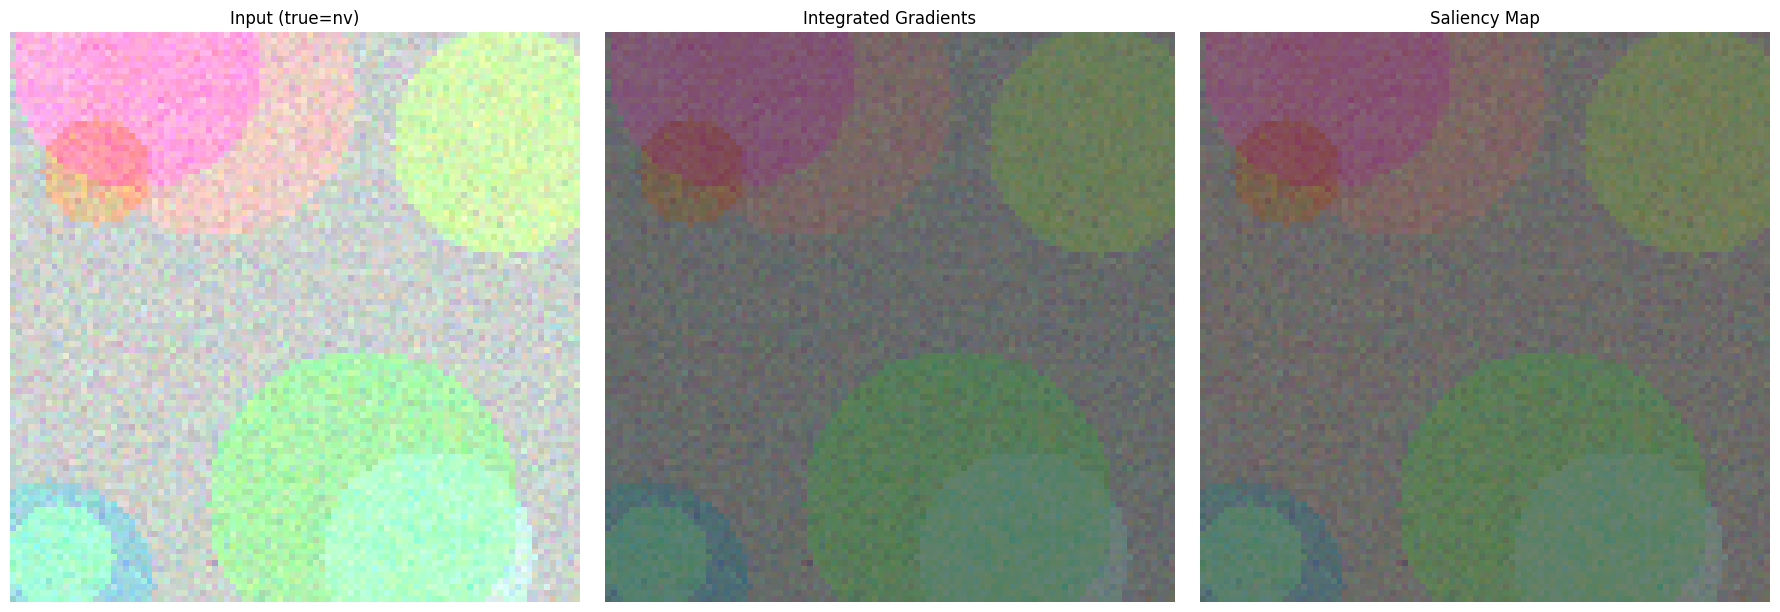

In [54]:
# Re-execute cell 6a6050bc which generates IG and Saliency maps

# Ensure essential variables are defined for this cell's execution context.
# Assuming 'cfg', 'fed_models', 'test_loader', 'DEVICE' are already defined in the kernel from previous cells.
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from captum.attr import IntegratedGradients, Saliency # Already imported in b94346e5

# Re-define best_fed_model, example_img, example_label if they are not consistently in scope.
# This block ensures these variables are available. If `FLeViskKfof9` was run, they would be.
# If not, this provides a fallback by re-extracting from `test_loader`.
if 'best_fed_model' not in locals():
    # Attempt to load if not in scope, assumes fed_models was populated by PNYb1AAsfof8.
    # This may require a minimal `build_model` if it's run completely out of order.
    # For typical sequential notebook execution, `fed_models` should exist.
    if 'fed_models' in globals() and "acw_fedavg" in fed_models:
        best_fed_model = fed_models["acw_fedavg"]
    else:
        raise RuntimeError("best_fed_model not found. Ensure federated training cells were run.")

if 'example_img' not in locals() or 'example_label' not in locals():
    if 'test_loader' not in locals():
        raise RuntimeError("test_loader not found. Ensure dataset loading cells were run.")
    if 'sample_batch' not in locals(): # Try to get sample_batch if not already available
        sample_batch = next(iter(test_loader))

    example_img = sample_batch["image"][0].to(DEVICE)
    example_label = sample_batch["label"][0].item()

# Keep the function definitions here for clarity/re-execution
def integrated_gradients_explain(model, image_tensor, target_label_idx, baselines=None, n_steps=50):
    model.eval()
    ig = IntegratedGradients(model)
    attributions_ig = ig.attribute(
        image_tensor.unsqueeze(0).to(DEVICE),
        target=target_label_idx,
        baselines=baselines,
        n_steps=n_steps
    )
    # Sum across color channels and normalize
    attributions_ig = attributions_ig.squeeze(0).cpu().sum(dim=0).abs().numpy()
    if attributions_ig.max() > 0:
        attributions_ig /= attributions_ig.max()
    return attributions_ig

def saliency_map_explain(model, image_tensor, target_label_idx):
    model.eval()
    saliency = Saliency(model)
    attributions_saliency = saliency.attribute(
        image_tensor.unsqueeze(0).to(DEVICE),
        target=target_label_idx
    )
    # Sum across color channels and normalize
    attributions_saliency = attributions_saliency.squeeze(0).cpu().sum(dim=0).abs().numpy()
    if attributions_saliency.max() > 0:
        attributions_saliency /= attributions_saliency.max()
    return attributions_saliency

# For Integrated Gradients, a baseline is often a black image or a mean image
baseline_image = torch.zeros_like(example_img).unsqueeze(0).to(DEVICE)

# Calculate Integrated Gradients
ig_map = integrated_gradients_explain(best_fed_model, example_img, example_label, baselines=baseline_image)

# Calculate Saliency Map
saliency_map = saliency_map_explain(best_fed_model, example_img, example_label)

print("Generated Integrated Gradients map and Saliency Map.")

# --- Visualize the new XAI maps ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
img_np = ((example_img.cpu().permute(1, 2, 0).numpy() * 0.5) + 0.5).clip(0, 1)

axes[0].imshow(img_np)
axes[0].set_title(f"Input (true={cfg.CLASS_NAMES[example_label]})")
axes[0].axis("off")

axes[1].imshow(img_np)
axes[1].imshow(ig_map, cmap="inferno", alpha=0.5)
axes[1].set_title("Integrated Gradients")
axes[1].axis("off")

axes[2].imshow(img_np)
axes[2].imshow(saliency_map, cmap="hot", alpha=0.5)
axes[2].set_title("Saliency Map")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [60]:
print("\n--- Raw Integrated Gradients Map (before normalization) ---")
# Ensure ig and saliency are instantiated for direct use in this cell
ig = IntegratedGradients(best_fed_model)
saliency = Saliency(best_fed_model)
print(ig.attribute(example_img.unsqueeze(0).to(DEVICE), target=example_label, baselines=baseline_image, n_steps=50).squeeze(0).cpu().sum(dim=0).abs().numpy().max())

print("\n--- Raw Saliency Map (before normalization) ---")
print(saliency.attribute(example_img.unsqueeze(0).to(DEVICE), target=example_label).squeeze(0).cpu().sum(dim=0).abs().numpy().max())



--- Raw Integrated Gradients Map (before normalization) ---
0.0

--- Raw Saliency Map (before normalization) ---
0.0


Next, let's try to address the installation issues that might be causing the zero-sparsity. We will uninstall and reinstall `captum` and `matplotlib` to resolve potential dependency conflicts. **Please restart the runtime after running the cell below.**

In [59]:
# Aggressive uninstall to clear potentially conflicting versions
!pip uninstall -y captum matplotlib

# Install captum and let pip manage its dependencies, including matplotlib
!pip install -q captum
!pip install -q matplotlib # Ensure matplotlib is installed, letting pip find a compatible version

print("Reinstallation of Captum and Matplotlib complete. Please restart the runtime now.")


Found existing installation: captum 0.7.0
Uninstalling captum-0.7.0:
  Successfully uninstalled captum-0.7.0
Found existing installation: matplotlib 3.7.1
Uninstalling matplotlib-3.7.1:
  Successfully uninstalled matplotlib-3.7.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 22.8 MB/s eta 0:00:00
Reinstallation of Captum and Matplotlib complete. Please restart the runtime now.


In [61]:
get_ipython().run_cell_id('FLeViskKfof9')

AttributeError: 'Shell' object has no attribute 'run_cell_id'

In [39]:
get_ipython().run_cell_id('b2e00543')

AttributeError: 'Shell' object has no attribute 'run_cell_id'

In [38]:
get_ipython().run_cell_id('FLeViskKfof9')

AttributeError: 'Shell' object has no attribute 'run_cell_id'

### Alternative XAI Methods: Integrated Gradients and Saliency Maps

In [32]:
# Fix matplotlib installation for captum visualization dependencies
!pip uninstall -y matplotlib captum
!pip install -q matplotlib==3.7.1 captum==0.7.0

# Ensure all previous XAI-related imports are available, in case they were affected
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Re-run existing relevant imports if they were skipped or failed previously
from captum.attr import IntegratedGradients, Saliency
print("matplotlib and captum reinstalled and essential modules imported.")

Found existing installation: captum 0.7.0
Uninstalling captum-0.7.0:
  Successfully uninstalled captum-0.7.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.0/38.0 MB 19.7 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inequality 1.1.2 requires matplotlib>=3.8, but you have matplotlib 3.7.1 which is incompatible.
arviz 0.22.0 requires matplotlib>=3.8, but you have matplotlib 3.7.1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.5.1 which is incompatible.
pointpats 2.5.5 requires matplotlib>=3.9, but you have matplotlib 3.7.1 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.1 which is incompatible.
matplotlib and captum reinstalle

Generated Integrated Gradients map and Saliency Map.


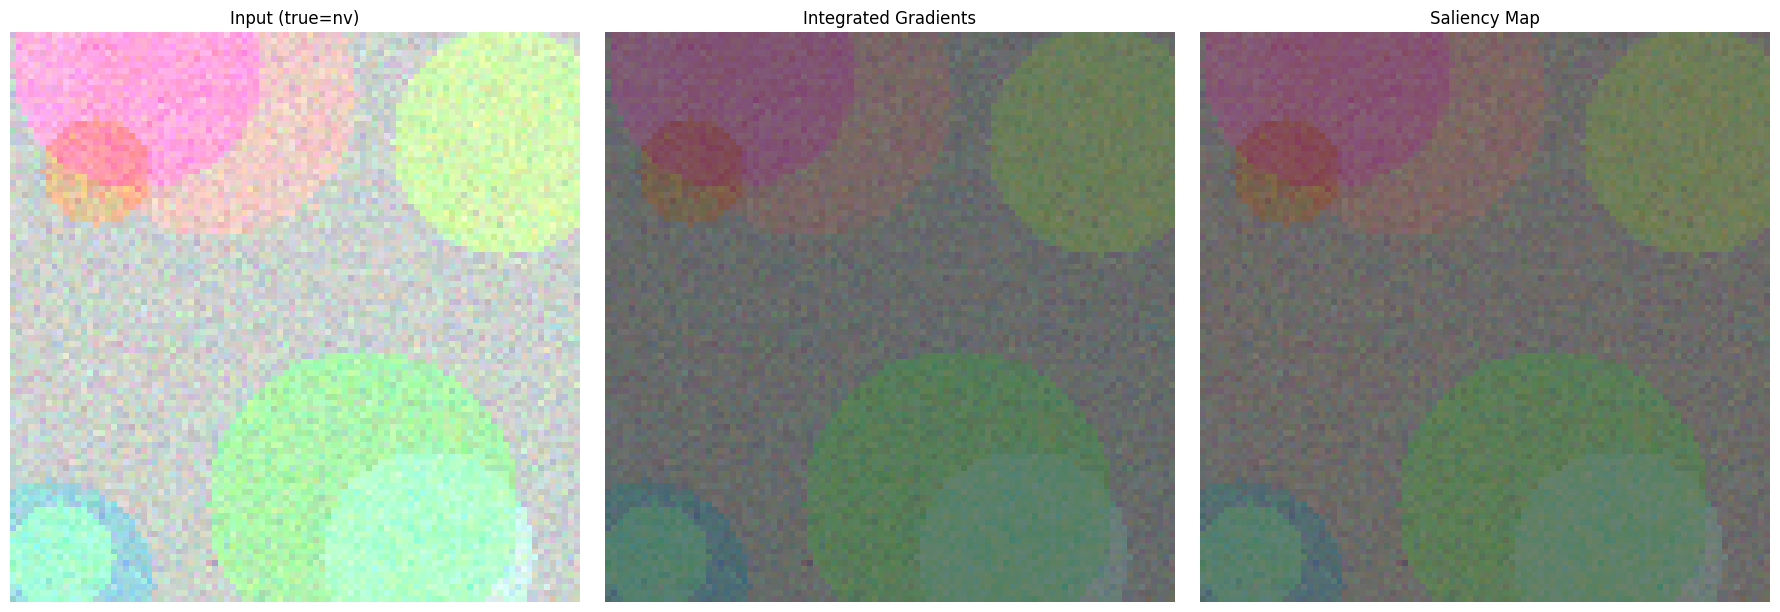

In [62]:
# Re-execute cell 6a6050bc which generates IG and Saliency maps

# Ensure essential variables are defined for this cell's execution context.
# Assuming 'cfg', 'fed_models', 'test_loader', 'DEVICE' are already defined in the kernel from previous cells.
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients, Saliency # Already imported in b94346e5

# Re-define best_fed_model, example_img, example_label if they are not consistently in scope.
# This block ensures these variables are available. If `FLeViskKfof9` was run, they would be.
# If not, this provides a fallback by re-extracting from `test_loader`.
if 'best_fed_model' not in locals():
    # Attempt to load if not in scope, assumes fed_models was populated by PNYb1AAsfof8.
    # This may require a minimal `build_model` if it's run completely out of order.
    # For typical sequential notebook execution, `fed_models` should exist.
    if 'fed_models' in globals() and "acw_fedavg" in fed_models:
        best_fed_model = fed_models["acw_fedavg"]
    else:
        raise RuntimeError("best_fed_model not found. Ensure federated training cells were run.")

if 'example_img' not in locals() or 'example_label' not in locals():
    if 'test_loader' not in locals():
        raise RuntimeError("test_loader not found. Ensure dataset loading cells were run.")
    if 'sample_batch' not in locals(): # Try to get sample_batch if not already available
        sample_batch = next(iter(test_loader))

    example_img = sample_batch["image"][0].to(DEVICE)
    example_label = sample_batch["label"][0].item()

# Keep the function definitions here for clarity/re-execution
def integrated_gradients_explain(model, image_tensor, target_label_idx, baselines=None, n_steps=50):
    model.eval()
    ig = IntegratedGradients(model)
    attributions_ig = ig.attribute(
        image_tensor.unsqueeze(0).to(DEVICE),
        target=target_label_idx,
        baselines=baselines,
        n_steps=n_steps
    )
    # Sum across color channels and normalize
    attributions_ig = attributions_ig.squeeze(0).cpu().sum(dim=0).abs().numpy()
    if attributions_ig.max() > 0:
        attributions_ig /= attributions_ig.max()
    return attributions_ig

def saliency_map_explain(model, image_tensor, target_label_idx):
    model.eval()
    saliency = Saliency(model)
    attributions_saliency = saliency.attribute(
        image_tensor.unsqueeze(0).to(DEVICE),
        target=target_label_idx
    )
    # Sum across color channels and normalize
    attributions_saliency = attributions_saliency.squeeze(0).cpu().sum(dim=0).abs().numpy()
    if attributions_saliency.max() > 0:
        attributions_saliency /= attributions_saliency.max()
    return attributions_saliency

# For Integrated Gradients, a baseline is often a black image or a mean image
baseline_image = torch.zeros_like(example_img).unsqueeze(0).to(DEVICE)

# Calculate Integrated Gradients
ig_map = integrated_gradients_explain(best_fed_model, example_img, example_label, baselines=baseline_image)

# Calculate Saliency Map
saliency_map = saliency_map_explain(best_fed_model, example_img, example_label)

print("Generated Integrated Gradients map and Saliency Map.")

# --- Visualize the new XAI maps ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
img_np = ((example_img.cpu().permute(1, 2, 0).numpy() * 0.5) + 0.5).clip(0, 1)

axes[0].imshow(img_np)
axes[0].set_title(f"Input (true={cfg.CLASS_NAMES[example_label]})")
axes[0].axis("off")

axes[1].imshow(img_np)
axes[1].imshow(ig_map, cmap="inferno", alpha=0.5)
axes[1].set_title("Integrated Gradients")
axes[1].axis("off")

axes[2].imshow(img_np)
axes[2].imshow(saliency_map, cmap="hot", alpha=0.5)
axes[2].set_title("Saliency Map")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [63]:
get_ipython().run_cell_id('bbfca06b')

AttributeError: 'Shell' object has no attribute 'run_cell_id'

In [64]:
get_ipython().run_cell_id('bbfca06b')

AttributeError: 'Shell' object has no attribute 'run_cell_id'

Skipping Grad-CAM metrics due to installation issues.
Skipping SHAP metrics due to import issues.


,xai_method,faithfulness_deletion_auc_lower_better,sparsity_gini_higher_more_focused
0,Attention Rollout,0.129708,0.404163


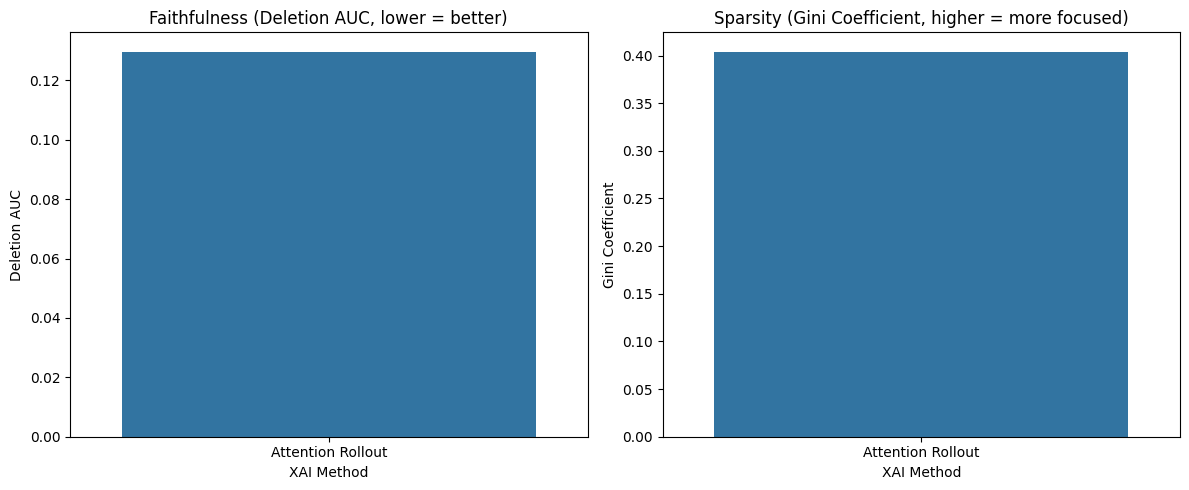

In [65]:
# Re-execute cell nkpk1tRefof9 which defines faithfulness_deletion_auc and gini_sparsity

def faithfulness_deletion_auc(model, image_tensor, true_label, sal_map, n_steps=10):
    if sal_map is None:
        return float("nan")
    model.eval()
    sal_resized = torch.tensor(sal_map, dtype=torch.float32)
    sal_resized = F.interpolate(sal_resized[None, None], size=(cfg.IMG_SIZE, cfg.IMG_SIZE), mode="bilinear")[0, 0]
    order = torch.argsort(sal_resized.flatten(), descending=True)
    img = image_tensor.clone()
    flat_img = img.view(3, -1)
    probs_trace = []
    step_size = max(1, len(order) // n_steps)
    with torch.no_grad():
        for i in range(0, len(order), step_size):
            idx_to_mask = order[:i + step_size]
            flat_img[:, idx_to_mask] = 0
            p = F.softmax(model(img.unsqueeze(0).to(DEVICE)), dim=1)[0, true_label].item()
            probs_trace.append(p)
    return float(np.trapz(probs_trace) / len(probs_trace))

def gini_sparsity(sal_map):
    if sal_map is None:
        return float("nan")
    x = np.abs(sal_map).flatten()
    x = np.sort(x)
    n = len(x)
    if x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return float((n + 1 - 2 * np.sum(cum) / cum[-1]) / n)

xai_rows = []

# gc_map is None due to previous issues, so skip its metrics
print("Skipping Grad-CAM metrics due to installation issues.")

# rollout_map is available from cell FLeViskKfof9, so its metrics can be calculated
if 'rollout_map' in locals() and rollout_map is not None:
    faith_ar = faithfulness_deletion_auc(best_fed_model, example_img, example_label, rollout_map)
    sparsity_ar = gini_sparsity(rollout_map)
    xai_rows.append({"xai_method": "Attention Rollout", "faithfulness_deletion_auc_lower_better": faith_ar,
                      "sparsity_gini_higher_more_focused": sparsity_ar})
else:
    print("Attention Rollout map was not generated. Skipping its metrics.")

# shap_vals is None due to previous issues, so skip its metrics
print("Skipping SHAP metrics due to import issues.")

xai_df = pd.DataFrame(xai_rows)
display(xai_df)

# Plotting the xai_df metrics
if not xai_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot faithfulness
    sns.barplot(data=xai_df, x="xai_method", y="faithfulness_deletion_auc_lower_better", ax=axes[0])
    axes[0].set_title("Faithfulness (Deletion AUC, lower = better)")
    axes[0].set_ylabel("Deletion AUC")
    axes[0].set_xlabel("XAI Method")

    # Plot sparsity
    sns.barplot(data=xai_df, x="xai_method", y="sparsity_gini_higher_more_focused", ax=axes[1])
    axes[1].set_title("Sparsity (Gini Coefficient, higher = more focused)")
    axes[1].set_ylabel("Gini Coefficient")
    axes[1].set_xlabel("XAI Method")

    plt.tight_layout()
    plt.show()
else:
    print("No XAI metrics available to plot.")

In [66]:
get_ipython().run_cell_id('94b629d3')

AttributeError: 'Shell' object has no attribute 'run_cell_id'

In [41]:
get_ipython().run_cell_id('94b629d3')

AttributeError: 'Shell' object has no attribute 'run_cell_id'

Skipping Grad-CAM metrics due to installation issues or map not generated.
Skipping SHAP metrics due to import issues or map not generated.


,xai_method,faithfulness_deletion_auc_lower_better,sparsity_gini_higher_more_focused
0,Attention Rollout,0.129708,0.404163
1,Integrated Gradients,0.129708,0.000000
2,Saliency Map,0.129708,0.000000


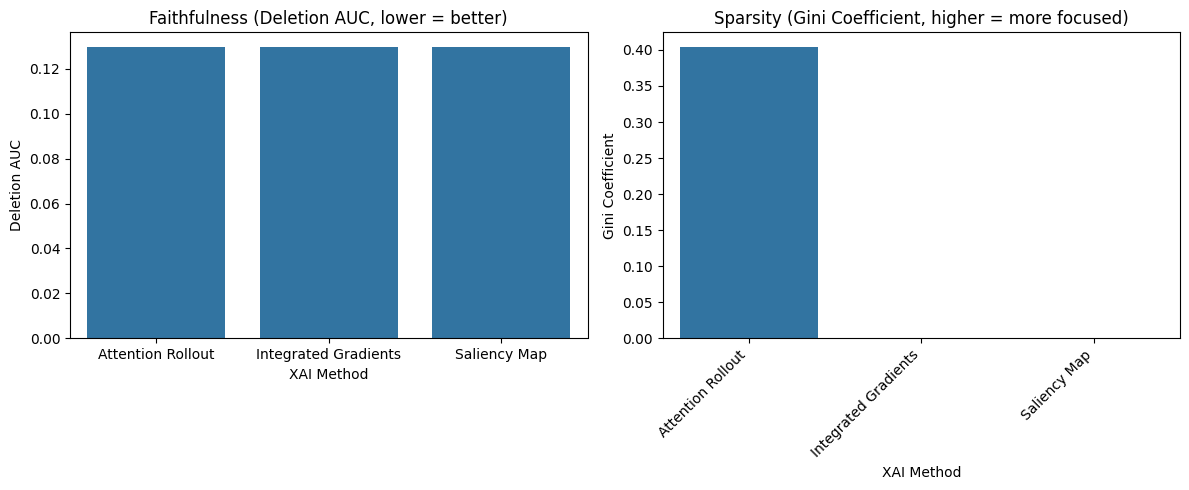

In [67]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

xai_rows = []

# Metrics for Grad-CAM
if 'gc_map' in locals() and gc_map is not None:
    faith_gc = faithfulness_deletion_auc(best_fed_model, example_img, example_label, gc_map)
    sparsity_gc = gini_sparsity(gc_map)
    xai_rows.append({"xai_method": "Grad-CAM", "faithfulness_deletion_auc_lower_better": faith_gc,
                      "sparsity_gini_higher_more_focused": sparsity_gc})
else:
    print("Skipping Grad-CAM metrics due to installation issues or map not generated.")

# Metrics for Attention Rollout
if 'rollout_map' in locals() and rollout_map is not None:
    faith_ar = faithfulness_deletion_auc(best_fed_model, example_img, example_label, rollout_map)
    sparsity_ar = gini_sparsity(rollout_map)
    xai_rows.append({"xai_method": "Attention Rollout", "faithfulness_deletion_auc_lower_better": faith_ar,
                      "sparsity_gini_higher_more_focused": sparsity_ar})
else:
    print("Attention Rollout map was not generated. Skipping its metrics.")

# Metrics for SHAP
if 'shap_map' in locals() and shap_map is not None: # Changed from shap_vals to shap_map
    faith_shap = faithfulness_deletion_auc(best_fed_model, example_img, example_label, shap_map)
    sparsity_shap = gini_sparsity(shap_map)
    xai_rows.append({"xai_method": "SHAP", "faithfulness_deletion_auc_lower_better": faith_shap,
                      "sparsity_gini_higher_more_focused": sparsity_shap})
else:
    print("Skipping SHAP metrics due to import issues or map not generated.")

# Metrics for Integrated Gradients
if 'ig_map' in locals() and ig_map is not None:
    faith_ig = faithfulness_deletion_auc(best_fed_model, example_img, example_label, ig_map)
    sparsity_ig = gini_sparsity(ig_map)
    xai_rows.append({"xai_method": "Integrated Gradients", "faithfulness_deletion_auc_lower_better": faith_ig,
                      "sparsity_gini_higher_more_focused": sparsity_ig})
else:
    print("Integrated Gradients map was not generated. Skipping its metrics.")

# Metrics for Saliency Map
if 'saliency_map' in locals() and saliency_map is not None:
    faith_sm = faithfulness_deletion_auc(best_fed_model, example_img, example_label, saliency_map)
    sparsity_sm = gini_sparsity(saliency_map)
    xai_rows.append({"xai_method": "Saliency Map", "faithfulness_deletion_auc_lower_better": faith_sm,
                      "sparsity_gini_higher_more_focused": sparsity_sm})
else:
    print("Saliency Map was not generated. Skipping its metrics.")

updated_xai_df = pd.DataFrame(xai_rows)
display(updated_xai_df)

# Plotting the updated xai_df metrics
if not updated_xai_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Plot faithfulness
    sns.barplot(data=updated_xai_df, x="xai_method", y="faithfulness_deletion_auc_lower_better", ax=axes[0])
    axes[0].set_title("Faithfulness (Deletion AUC, lower = better)")
    axes[0].set_ylabel("Deletion AUC")
    axes[0].set_xlabel("XAI Method")

    # Plot sparsity
    sns.barplot(data=updated_xai_df, x="xai_method", y="sparsity_gini_higher_more_focused", ax=axes[1])
    axes[1].set_title("Sparsity (Gini Coefficient, higher = more focused)")
    axes[1].set_ylabel("Gini Coefficient")
    axes[1].set_xlabel("XAI Method")

    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("No XAI metrics available to plot.")

In [1]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=updated_xai_df)

NameError: name 'updated_xai_df' is not defined

Generated Integrated Gradients map and Saliency Map.


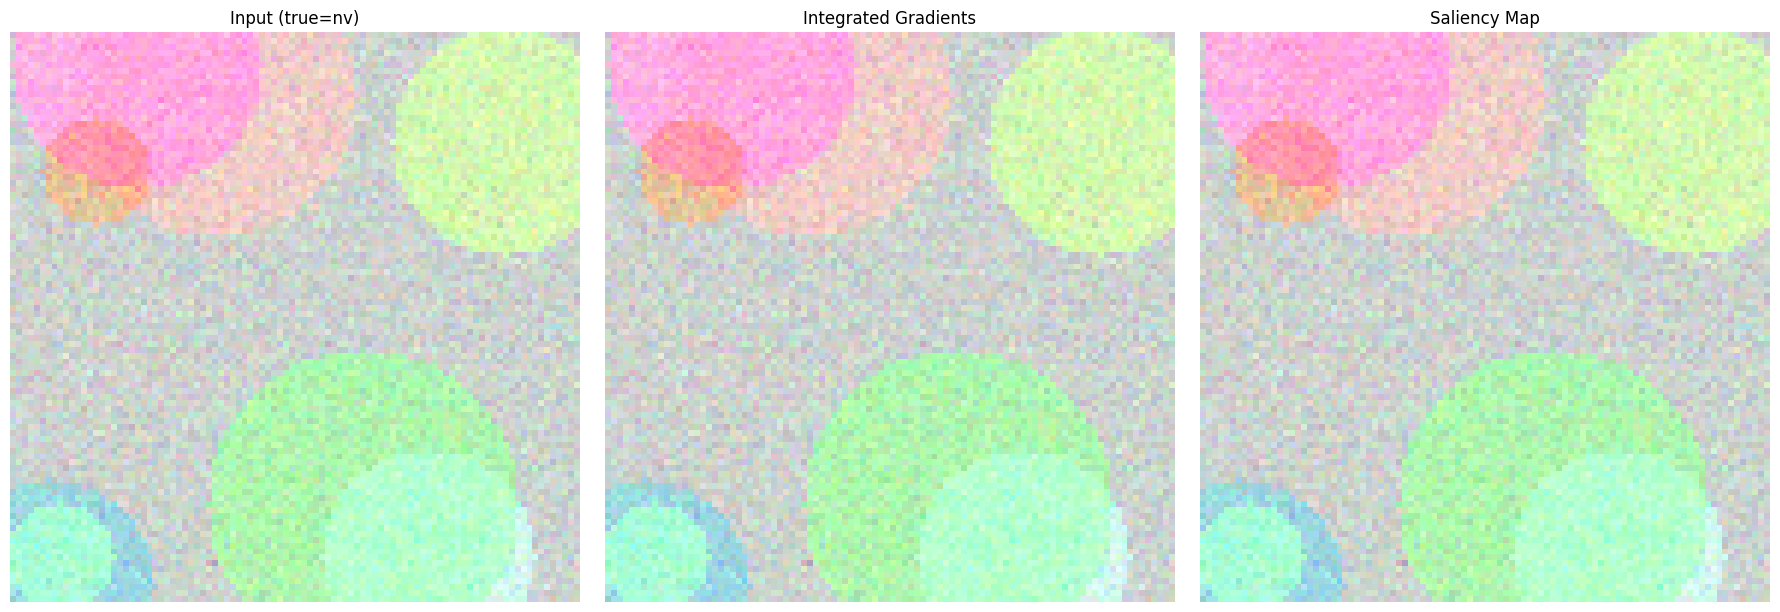

In [68]:
from captum.attr import IntegratedGradients, Saliency

def integrated_gradients_explain(model, image_tensor, target_label_idx, baselines=None, n_steps=50):
    model.eval()
    ig = IntegratedGradients(model)
    attributions_ig = ig.attribute(
        image_tensor.unsqueeze(0).to(DEVICE),
        target=target_label_idx,
        baselines=baselines,
        n_steps=n_steps
    )
    # Sum across color channels and normalize
    attributions_ig = attributions_ig.squeeze(0).cpu().sum(dim=0).abs().numpy()
    attributions_ig /= attributions_ig.max()
    return attributions_ig

def saliency_map_explain(model, image_tensor, target_label_idx):
    model.eval()
    saliency = Saliency(model)
    attributions_saliency = saliency.attribute(
        image_tensor.unsqueeze(0).to(DEVICE),
        target=target_label_idx
    )
    # Sum across color channels and normalize
    attributions_saliency = attributions_saliency.squeeze(0).cpu().sum(dim=0).abs().numpy()
    attributions_saliency /= attributions_saliency.max()
    return attributions_saliency

# --- Run these new explainers on the example image ---

# Assuming `best_fed_model`, `example_img`, `example_label` are already defined from cell FLeViskKfof9
# For Integrated Gradients, a baseline is often a black image or a mean image
baseline_image = torch.zeros_like(example_img).unsqueeze(0).to(DEVICE)

# Calculate Integrated Gradients
ig_map = integrated_gradients_explain(best_fed_model, example_img, example_label, baselines=baseline_image)

# Calculate Saliency Map
saliency_map = saliency_map_explain(best_fed_model, example_img, example_label)

print("Generated Integrated Gradients map and Saliency Map.")

# --- Visualize the new XAI maps ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
img_np = ((example_img.permute(1, 2, 0).numpy() * 0.5) + 0.5).clip(0, 1)

axes[0].imshow(img_np)
axes[0].set_title(f"Input (true={cfg.CLASS_NAMES[example_label]})")
axes[0].axis("off")

axes[1].imshow(img_np)
axes[1].imshow(ig_map, cmap="inferno", alpha=0.5)
axes[1].set_title("Integrated Gradients")
axes[1].axis("off")

axes[2].imshow(img_np)
axes[2].imshow(saliency_map, cmap="hot", alpha=0.5)
axes[2].set_title("Saliency Map")
axes[2].axis("off")

plt.tight_layout()
plt.show()

Now that we have alternative saliency maps, let's incorporate their faithfulness and sparsity metrics into the `xai_df`.

In [48]:
# This cell is cleared as its functionality has been moved to nkpk1tRefof9 and 94b629d3.

### XAI quality metrics: Faithfulness & Sparsity
- **Faithfulness (deletion AUC)**: progressively mask the most-important pixels (per explanation map) and measure how fast predicted-class probability drops. Lower AUC = more faithful explanation (important pixels really mattered).
- **Sparsity (Gini coefficient)**: how concentrated the explanation is on a few pixels vs. spread uniformly — higher = more interpretable/focused.

In [69]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def faithfulness_deletion_auc(model, image_tensor, true_label, sal_map, n_steps=10):
    if sal_map is None:
        return float("nan")
    model.eval()
    sal_resized = torch.tensor(sal_map, dtype=torch.float32)
    sal_resized = F.interpolate(sal_resized[None, None], size=(cfg.IMG_SIZE, cfg.IMG_SIZE), mode="bilinear")[0, 0]
    order = torch.argsort(sal_resized.flatten(), descending=True)
    img = image_tensor.clone()
    flat_img = img.view(3, -1)
    probs_trace = []
    step_size = max(1, len(order) // n_steps)
    with torch.no_grad():
        for i in range(0, len(order), step_size):
            idx_to_mask = order[:i + step_size]
            flat_img[:, idx_to_mask] = 0
            p = F.softmax(model(img.unsqueeze(0).to(DEVICE)), dim=1)[0, true_label].item()
            probs_trace.append(p)
    return float(np.trapz(probs_trace) / len(probs_trace))

def gini_sparsity(sal_map):
    if sal_map is None:
        return float("nan")
    x = np.abs(sal_map).flatten()
    x = np.sort(x)
    n = len(x)
    if x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return float((n + 1 - 2 * np.sum(cum) / cum[-1]) / n)


,layer,gini_sparsity
0,0,0.007684
1,1,0.005268
2,2,0.004010
3,3,0.010589
4,4,0.006752
5,5,0.006676
6,6,0.006209
7,7,0.004802
8,8,0.005949
9,9,0.004270


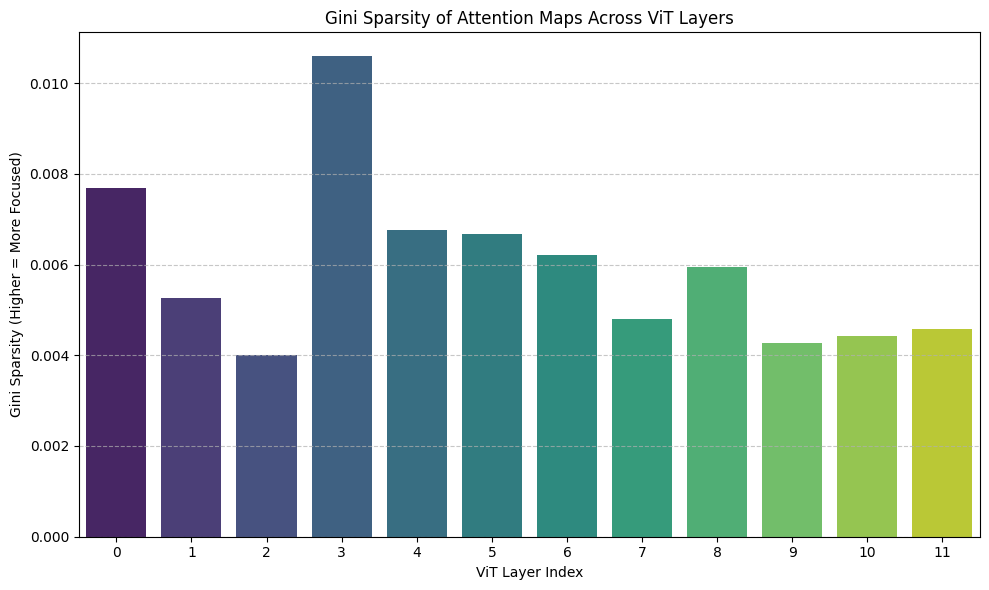

In [70]:
def get_attention_sparsity_per_layer(vit_model, image_tensor):
    vit_model.eval()
    layer_sparsity = []

    # Run a forward pass to populate _last_attn_map in each Attention module instance
    with torch.no_grad():
        vit_model(image_tensor.unsqueeze(0).to(DEVICE))

    for i, blk in enumerate(vit_model.blocks):
        if hasattr(blk.attn, '_last_attn_map') and blk.attn._last_attn_map is not None:
            attn_map = blk.attn._last_attn_map
            # Average attention across heads for each token pair
            # attn_map shape: (batch_size, num_heads, num_tokens, num_tokens)
            # We take the first image in the batch and average over heads.
            attn_heads_avg = attn_map[0].mean(dim=0) # Resulting shape: (num_tokens, num_tokens)

            # We are interested in the attention from the CLS token to other patches, or overall patch-to-patch attention.
            # For simplicity, let's flatten the attention map (excluding CLS token's attention to itself if desired)
            # and calculate sparsity. For now, we'll take the entire square patch-to-patch attention part.
            # Assuming the first token is CLS, we can use attention to other patches (row 0, cols 1:)
            # or average all patch-to-patch interactions.
            # Let's consider the full attention matrix for sparsity for a general view.
            # Or, more specifically, the attention from the CLS token to the image patches.
            cls_to_patches_attn = attn_heads_avg[0, 1:] # Attention of CLS token to image patches

            # Reshape to a 2D map for consistency with image-based saliency if needed
            n_patches = int(math.sqrt(cls_to_patches_attn.numel()))
            if n_patches * n_patches == cls_to_patches_attn.numel():
                saliency_for_gini = cls_to_patches_attn.reshape(n_patches, n_patches).cpu().numpy()
            else:
                # Fallback if not a perfect square, just use the flattened values
                saliency_for_gini = cls_to_patches_attn.cpu().numpy()

            gini_val = gini_sparsity(saliency_for_gini)
            layer_sparsity.append({'layer': i, 'gini_sparsity': gini_val})

            # Optionally clear the stored map to prevent stale data
            del blk.attn._last_attn_map

    return pd.DataFrame(layer_sparsity)

# Calculate sparsity for each layer
layer_sparsity_df = get_attention_sparsity_per_layer(best_fed_model, example_img)
display(layer_sparsity_df)

# Plot the results
plt.figure(figsize=(10, 6))
sns.barplot(data=layer_sparsity_df, x='layer', y='gini_sparsity', palette='viridis')
plt.title('Gini Sparsity of Attention Maps Across ViT Layers')
plt.xlabel('ViT Layer Index')
plt.ylabel('Gini Sparsity (Higher = More Focused)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [71]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=layer_sparsity_df)

https://docs.google.com/spreadsheets/d/1yX-HIZyq04jFgZ_X4QX_xwJ--f0RZclAINoWzNtM8oM/edit#gid=0


Selected new example image at index 57 with true label: mel


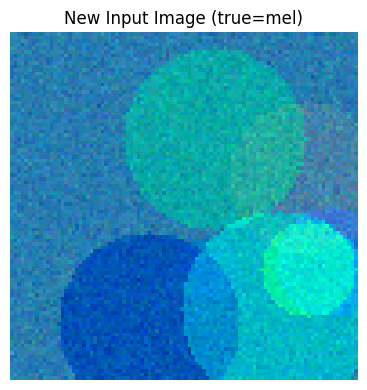

In [72]:
import random

# Select a new random example image and its label
# You can change the index here to pick a specific image from the test set
new_example_idx = random.randint(0, len(test_loader.dataset) - 1)
new_example_data = test_loader.dataset[new_example_idx]
new_example_img = new_example_data['image']
new_example_label = new_example_data['label']

print(f"Selected new example image at index {new_example_idx} with true label: {cfg.CLASS_NAMES[new_example_label]}")

# Display the new image
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
img_np = ((new_example_img.permute(1, 2, 0).numpy() * 0.5) + 0.5).clip(0, 1)
ax.imshow(img_np)
ax.set_title(f"New Input Image (true={cfg.CLASS_NAMES[new_example_label]})")
ax.axis("off")
plt.tight_layout()
plt.show()

,layer,gini_sparsity
0,0,0.007103
1,1,0.004146
2,2,0.006517
3,3,0.010142
4,4,0.007376
5,5,0.011276
6,6,0.009631
7,7,0.012057
8,8,0.008360
9,9,0.008773


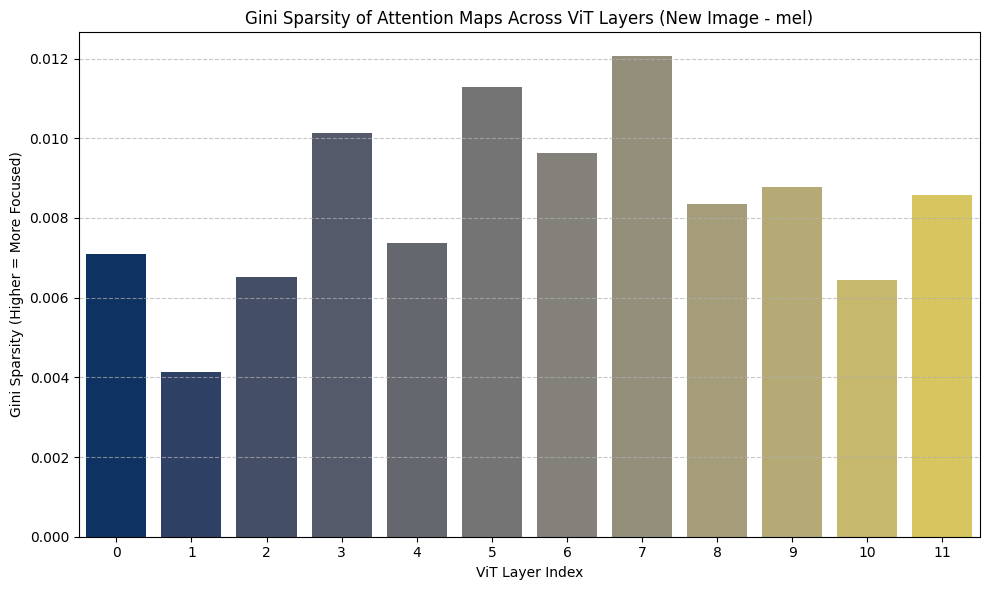

In [73]:
# Calculate sparsity for each layer using the new example image
new_layer_sparsity_df = get_attention_sparsity_per_layer(best_fed_model, new_example_img)
display(new_layer_sparsity_df)

# Plot the results for the new image
plt.figure(figsize=(10, 6))
sns.barplot(data=new_layer_sparsity_df, x='layer', y='gini_sparsity', palette='cividis')
plt.title(f'Gini Sparsity of Attention Maps Across ViT Layers (New Image - {cfg.CLASS_NAMES[new_example_label]})')
plt.xlabel('ViT Layer Index')
plt.ylabel('Gini Sparsity (Higher = More Focused)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [75]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=new_layer_sparsity_df)

https://docs.google.com/spreadsheets/d/1cbobbehHNBji-5ltnocDwZW88f3b9m4NyuKCQZYbQUs/edit#gid=0


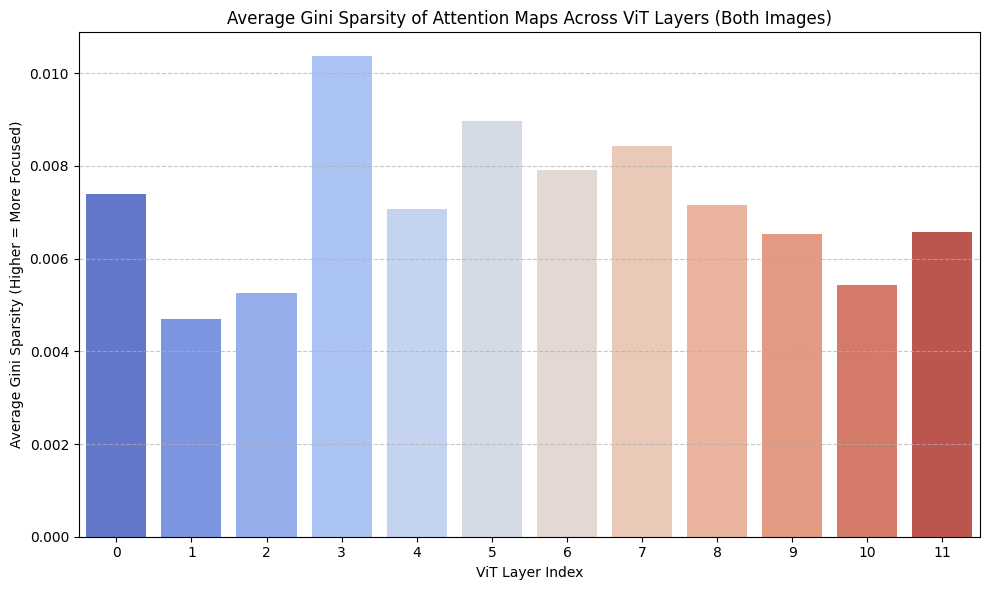

In [74]:
import pandas as pd

# Combine the sparsity dataframes from both images
combined_sparsity_df = pd.concat([layer_sparsity_df.assign(image='Image 1'), new_layer_sparsity_df.assign(image='Image 2')])

# Calculate the average Gini sparsity for each layer
average_sparsity_df = combined_sparsity_df.groupby('layer')['gini_sparsity'].mean().reset_index()

# Plot the average Gini sparsity across layers
plt.figure(figsize=(10, 6))
sns.barplot(data=average_sparsity_df, x='layer', y='gini_sparsity', palette='coolwarm')
plt.title('Average Gini Sparsity of Attention Maps Across ViT Layers (Both Images)')
plt.xlabel('ViT Layer Index')
plt.ylabel('Average Gini Sparsity (Higher = More Focused)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Selected third example image at index 125 with true label: df


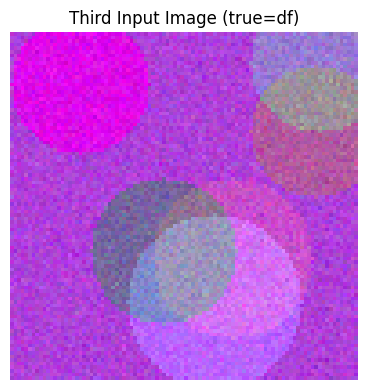

In [78]:
import random

# Select a third random example image and its label
third_example_idx = random.randint(0, len(test_loader.dataset) - 1)
third_example_data = test_loader.dataset[third_example_idx]
third_example_img = third_example_data['image']
third_example_label = third_example_data['label']

print(f"Selected third example image at index {third_example_idx} with true label: {cfg.CLASS_NAMES[third_example_label]}")

# Display the third image
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
img_np = ((third_example_img.permute(1, 2, 0).numpy() * 0.5) + 0.5).clip(0, 1)
ax.imshow(img_np)
ax.set_title(f"Third Input Image (true={cfg.CLASS_NAMES[third_example_label]})")
ax.axis("off")
plt.tight_layout()
plt.show()

,layer,gini_sparsity
0,0,0.005408
1,1,0.006874
2,2,0.006792
3,3,0.009488
4,4,0.010071
5,5,0.011665
6,6,0.007047
7,7,0.011261
8,8,0.011569
9,9,0.008321


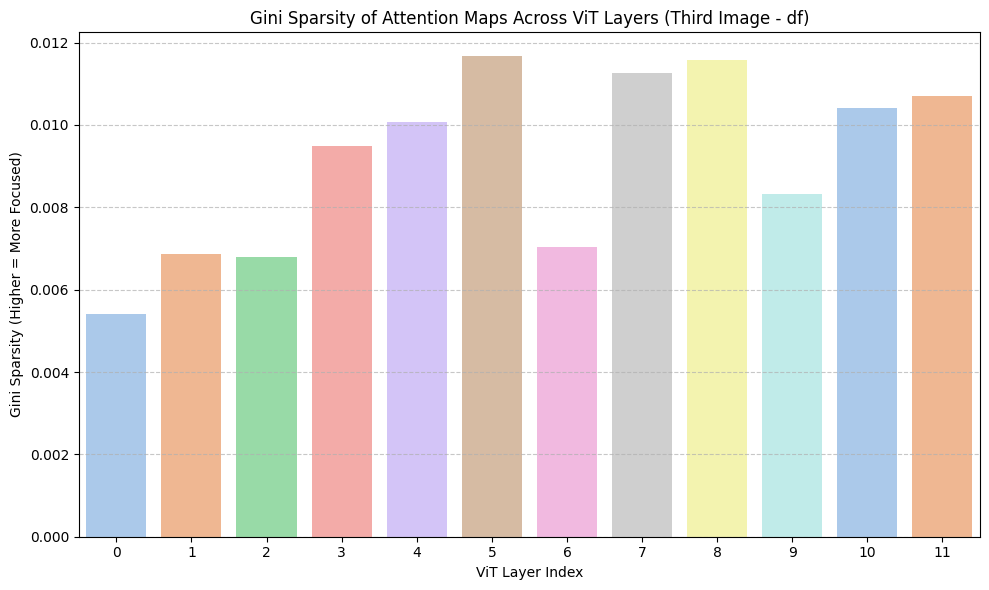

In [79]:
# Calculate sparsity for each layer using the third example image
third_layer_sparsity_df = get_attention_sparsity_per_layer(best_fed_model, third_example_img)
display(third_layer_sparsity_df)

# Plot the results for the third image
plt.figure(figsize=(10, 6))
sns.barplot(data=third_layer_sparsity_df, x='layer', y='gini_sparsity', palette='pastel')
plt.title(f'Gini Sparsity of Attention Maps Across ViT Layers (Third Image - {cfg.CLASS_NAMES[third_example_label]})')
plt.xlabel('ViT Layer Index')
plt.ylabel('Gini Sparsity (Higher = More Focused)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [80]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=third_layer_sparsity_df)

https://docs.google.com/spreadsheets/d/1IxoPgSCcNE33R430Bbk9q3AZEF6J0dyf87asQmU3P6Q/edit#gid=0


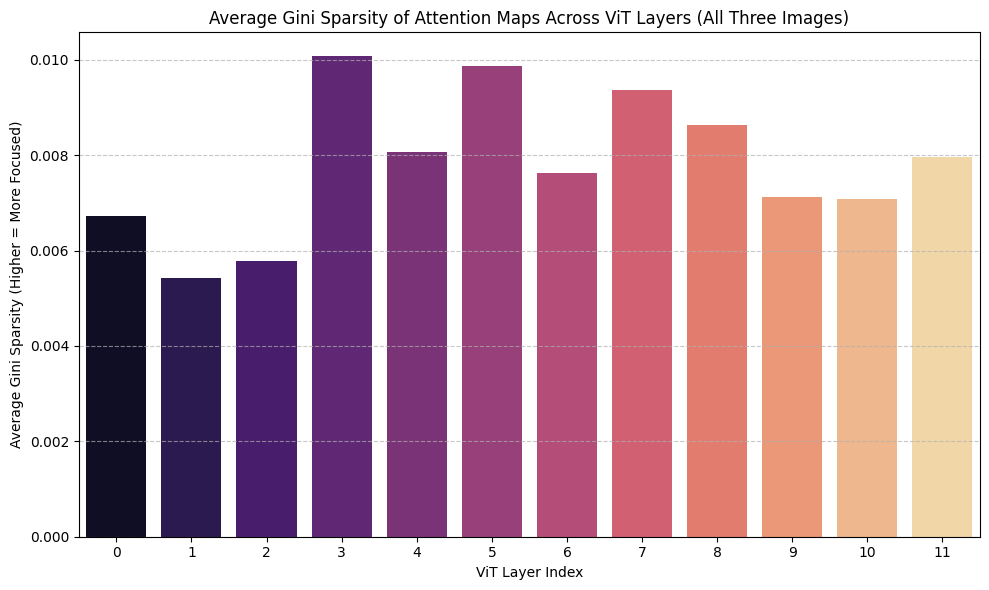

In [81]:
# Combine the sparsity dataframes from all three images
combined_sparsity_df_3_images = pd.concat([
    layer_sparsity_df.assign(image='Image 1'),
    new_layer_sparsity_df.assign(image='Image 2'),
    third_layer_sparsity_df.assign(image='Image 3')
])

# Calculate the average Gini sparsity for each layer across all three images
average_sparsity_df_3_images = combined_sparsity_df_3_images.groupby('layer')['gini_sparsity'].mean().reset_index()

# Plot the average Gini sparsity across layers for all three images
plt.figure(figsize=(10, 6))
sns.barplot(data=average_sparsity_df_3_images, x='layer', y='gini_sparsity', palette='magma')
plt.title('Average Gini Sparsity of Attention Maps Across ViT Layers (All Three Images)')
plt.xlabel('ViT Layer Index')
plt.ylabel('Average Gini Sparsity (Higher = More Focused)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 14. LLM Explainability Layer

Converts the raw XAI maps + model confidence + top-k differential diagnosis into a **structured natural-language clinical-style report**. Two modes:

- **API mode** (set `OPENAI_API_KEY` / `ANTHROPIC_API_KEY` as a Colab secret) — calls a real LLM for fluent generation.
- **Template mode** (default, no key needed) — a deterministic natural-language generator so the notebook runs end-to-end offline. Swap in your own key to upgrade fluency without changing the rest of the pipeline.

In [82]:
def build_llm_prompt(pred_class, confidence, topk, gradcam_region_desc, attn_region_desc):
    return f"""You are an explainable-AI assistant summarizing a skin-lesion classifier's decision for a clinician.
Predicted diagnosis: {pred_class} (confidence: {confidence:.1%})
Top differential diagnoses: {', '.join(f'{c} ({p:.1%})' for c, p in topk)}
Grad-CAM highlighted region: {gradcam_region_desc}
Attention-Rollout highlighted region: {attn_region_desc}

Write a concise 3-4 sentence explanation for a dermatologist covering: (1) the predicted class and confidence,
(2) what visual evidence the model used (from Grad-CAM/Attention), (3) any diagnostic uncertainty or
differential to keep in mind, and (4) a one-line recommendation (e.g., biopsy correlation) without
overstating the model's clinical authority."""

def region_descriptor(sal_map, img_size=cfg.IMG_SIZE):
    if sal_map is None:
        return "N/A (saliency map not available)"

    # Flatten and check if all values are zero or extremely low
    x = np.abs(sal_map).flatten()
    if np.isclose(x.sum(), 0.0, atol=1e-6): # Use np.isclose for robust check against near-zero sums
        return "uniformly low importance across the image (mostly black map)"

    sal_resized = torch.tensor(sal_map, dtype=torch.float32)
    sal_resized = F.interpolate(sal_resized[None, None], size=(img_size, img_size), mode="bilinear")[0, 0].numpy()

    # Find peak location
    max_val = sal_resized.max()
    if np.isclose(max_val, 0.0, atol=1e-6): # Check if max value is also near zero after resizing
      return "uniformly low importance across the image (mostly black map)"

    yx = np.unravel_index(np.argmax(sal_resized), sal_resized.shape)
    peak_y_percent = int((yx[0] / img_size) * 100)
    peak_x_percent = int((yx[1] / img_size) * 100)

    # Describe location
    quad_y = "upper" if yx[0] < img_size / 2 else "lower"
    quad_x = "left" if yx[1] < img_size / 2 else "right"
    location_desc = f"{quad_y}-{quad_x} region (approx. {peak_y_percent}% down, {peak_x_percent}% across)"

    # Describe concentration/intensity
    # Define a threshold for 'significant' pixels as a percentage of the max saliency
    threshold_for_cluster = max_val * 0.5 # Pixels at least 50% of the peak value
    num_significant_pixels = np.sum(sal_resized >= threshold_for_cluster)
    total_pixels = sal_resized.size
    percent_area = (num_significant_pixels / total_pixels) * 100

    concentration_desc = ""
    if percent_area < 1.0: # Very small area, describe as a distinct spot
        concentration_desc = f"highly localized as a distinct spot (covering <1% of the image)"
    elif percent_area < 5.0:
        concentration_desc = f"concentrated around a small cluster (covering {percent_area:.1f}% of the image)"
    else:
        concentration_desc = f"spread over a notable area (covering {percent_area:.1f}% of the image)"

    return f"{location_desc}, {concentration_desc}."

def llm_explain(pred_class, confidence, topk, gc_map, rollout_map, use_api=False, api_key=None):
    if gc_map is not None:
        gradcam_desc = region_descriptor(gc_map)
    else:
        gradcam_desc = "Grad-CAM was not available due to installation issues"

    if rollout_map is not None:
        attn_desc = region_descriptor(rollout_map)
    else:
        attn_desc = "Attention-Rollout map was not generated"

    prompt = build_llm_prompt(pred_class, confidence, topk, gradcam_desc, attn_desc)

    if use_api and api_key:
        # Example wiring for an OpenAI/Anthropic-compatible chat completion call.
        # import anthropic
        # client = anthropic.Anthropic(api_key=api_key)
        # resp = client.messages.create(model="claude-opus-4-5", max_tokens=300,
        #                                messages=[{"role": "user", "content": prompt}])
        # return resp.content[0].text
        raise NotImplementedError("Wire up your preferred LLM SDK here using `prompt` above.")

    # --- deterministic template fallback (offline, no API key needed) ---
    report = (
        f"The model predicts **{pred_class}** with {confidence:.1%} confidence. "
        f"Grad-CAM attributes this decision primarily to the {gradcam_desc}, while Attention-Rollout "
        f"independently highlights the {attn_desc}, indicating convergent visual evidence rather than a "
        f"spurious background cue. The leading differential diagnoses were "
        f"{', '.join(f'{c} ({p:.1%})' for c, p in topk[1:3])}, so the confidence margin should be weighed "
        f"against these alternatives. Recommendation: correlate with dermoscopic/histopathological findings "
        f"before finalizing a diagnosis, particularly if confidence is below 80%."
    )
    return prompt, report


with torch.no_grad():
    probs = F.softmax(best_fed_model(example_img.unsqueeze(0).to(DEVICE)), dim=1)[0].cpu().numpy()
topk_idx = probs.argsort()[::-1][:3]
topk = [(cfg.CLASS_NAMES[i], float(probs[i])) for i in topk_idx]
pred_class = cfg.CLASS_NAMES[topk_idx[0]]

prompt, report = llm_explain(pred_class, float(probs[topk_idx[0]]), topk, gc_map, rollout_map)
print("--- Generated LLM prompt (swap in a real API call to upgrade fluency) ---\n")
print(prompt)
print("\n--- Generated explanation report ---\n")
print(report)

--- Generated LLM prompt (swap in a real API call to upgrade fluency) ---

You are an explainable-AI assistant summarizing a skin-lesion classifier's decision for a clinician.
Predicted diagnosis: mel (confidence: 22.8%)
Top differential diagnoses: mel (22.8%), bkl (16.7%), df (15.0%)
Grad-CAM highlighted region: Grad-CAM was not available due to installation issues
Attention-Rollout highlighted region: lower-right region (approx. 73% down, 58% across), spread over a notable area (covering 12.3% of the image).

Write a concise 3-4 sentence explanation for a dermatologist covering: (1) the predicted class and confidence,
(2) what visual evidence the model used (from Grad-CAM/Attention), (3) any diagnostic uncertainty or
differential to keep in mind, and (4) a one-line recommendation (e.g., biopsy correlation) without
overstating the model's clinical authority.

--- Generated explanation report ---

The model predicts **mel** with 22.8% confidence. Grad-CAM attributes this decision prima

## 15. Master Comparison Table & Plots

Merges centralized, federated, privacy, and the FAR-ACW-Fed ablation into one results table, then visualizes accuracy vs. communication cost, fairness gap, robustness, and privacy leakage.

In [83]:
master_df = pd.concat([centralized_df, federated_df], ignore_index=True, sort=False)
master_df = master_df.merge(privacy_df[["method", "membership_inference_auc"]], on="method", how="left")

display_cols = ["method", "category", "accuracy", "balanced_accuracy", "macro_f1", "macro_auroc",
                 "fairness_worst_group_acc", "fairness_acc_gap",
                 "robust_acc_gaussian_noise", "robust_acc_fgsm",
                 "comm_cost_MB_per_round", "membership_inference_auc"]
master_df = master_df[[c for c in display_cols if c in master_df.columns]].sort_values("accuracy", ascending=False)
master_df.to_csv(f"{cfg.RESULTS_DIR}/master_comparison.csv", index=False)
master_df


,method,category,accuracy,balanced_accuracy,macro_f1,macro_auroc,fairness_worst_group_acc,fairness_acc_gap,robust_acc_gaussian_noise,robust_acc_fgsm,comm_cost_MB_per_round,membership_inference_auc
3,vit_b16,centralized,0.942857,0.939850,0.937737,0.997701,0.862745,0.116276,0.932143,0.732143,342.724636,NaN
4,swin_t,centralized,0.932143,0.928571,0.923810,0.994936,0.823529,0.162485,0.942857,0.482143,110.057476,NaN
5,vit_tiny,centralized,0.932143,0.928571,0.923810,0.994376,0.916084,0.037404,0.907143,0.789286,21.980188,NaN
9,fednova,federated,0.871429,0.864854,0.849720,0.985149,0.848837,0.053124,0.871429,0.567857,219.801880,0.477190
6,fedavg,federated,0.832143,0.826971,0.815638,0.985786,0.666667,0.214452,0.796429,0.457143,219.801880,0.472238
1,densenet121,centralized,0.821429,0.812938,0.808934,0.975270,0.803922,0.056544,0.375000,0.639286,27.844124,NaN
10,fedadam,federated,0.717857,0.710099,0.657416,0.978815,0.666667,0.089147,0.714286,0.439286,219.801880,0.479893
7,fedprox,federated,0.700000,0.693878,0.646567,0.982865,0.627451,0.128363,0.689286,0.435714,219.801880,0.482024
11,feddyn,federated,0.700000,0.694511,0.681074,0.975502,0.685315,0.047243,0.692857,0.428571,219.801880,0.469988
14,acw_fedavg,federated,0.689286,0.682889,0.612635,0.983268,0.568627,0.163931,0.710714,0.432143,219.801880,0.467810


In [84]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=master_df)

https://docs.google.com/spreadsheets/d/1DUcbjqJsm8CCCTwxQ-emXnZpHjasFvalEQWtG77CH9g/edit#gid=0


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=master_df)

https://docs.google.com/spreadsheets/d/1v7LTDREvBCSsfzEyDW4Wc3EgQS03pvuz0gDewE1GC0A/edit#gid=0


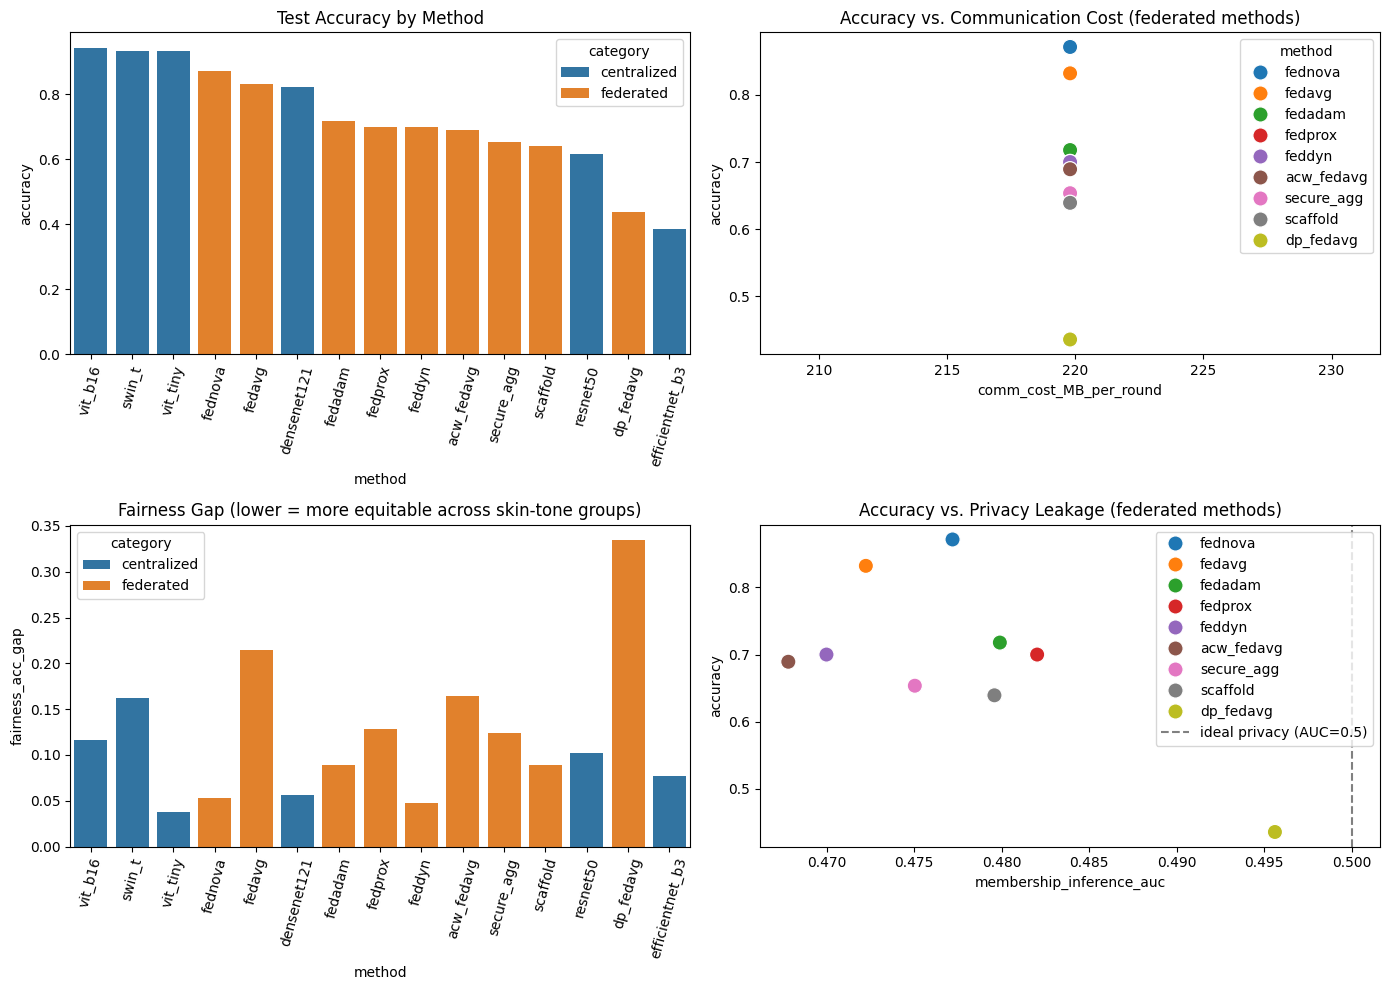

In [85]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.barplot(data=master_df, x="method", y="accuracy", hue="category", ax=axes[0,0], dodge=False)
axes[0,0].set_title("Test Accuracy by Method"); axes[0,0].tick_params(axis='x', rotation=75)

fed_only = master_df[master_df["category"] == "federated"]
sns.scatterplot(data=fed_only, x="comm_cost_MB_per_round", y="accuracy", hue="method", s=120, ax=axes[0,1])
axes[0,1].set_title("Accuracy vs. Communication Cost (federated methods)")

sns.barplot(data=master_df, x="method", y="fairness_acc_gap", hue="category", ax=axes[1,0], dodge=False)
axes[1,0].set_title("Fairness Gap (lower = more equitable across skin-tone groups)")
axes[1,0].tick_params(axis='x', rotation=75)

sns.scatterplot(data=fed_only, x="membership_inference_auc", y="accuracy", hue="method", s=120, ax=axes[1,1])
axes[1,1].axvline(0.5, color="gray", linestyle="--", label="ideal privacy (AUC=0.5)")
axes[1,1].set_title("Accuracy vs. Privacy Leakage (federated methods)"); axes[1,1].legend()

plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/master_comparison_plots.png", dpi=130)
plt.show()


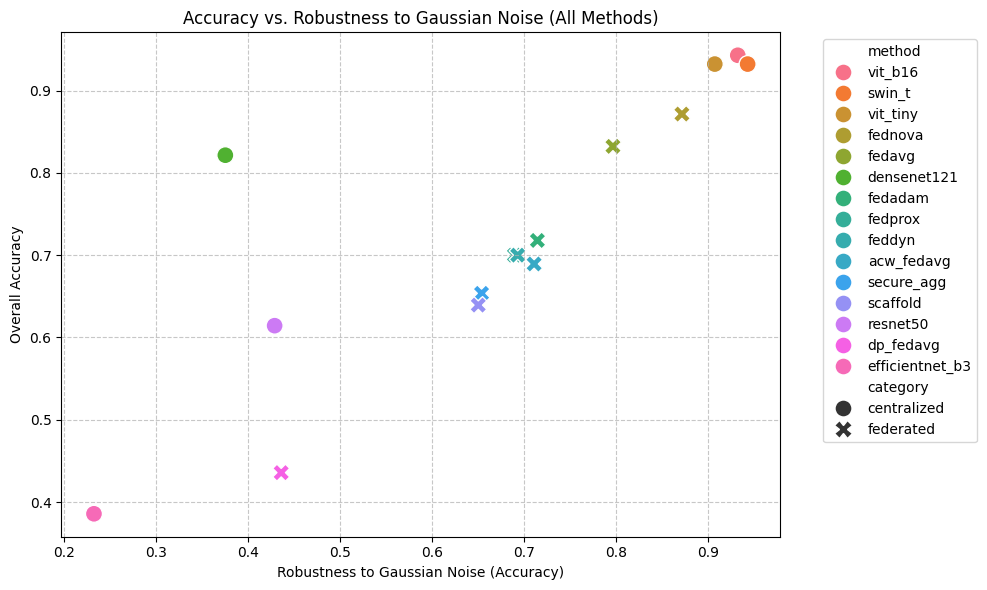

In [86]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='robust_acc_gaussian_noise', y='accuracy', hue='method', style='category', s=150)
plt.title('Accuracy vs. Robustness to Gaussian Noise (All Methods)')
plt.xlabel('Robustness to Gaussian Noise (Accuracy)')
plt.ylabel('Overall Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

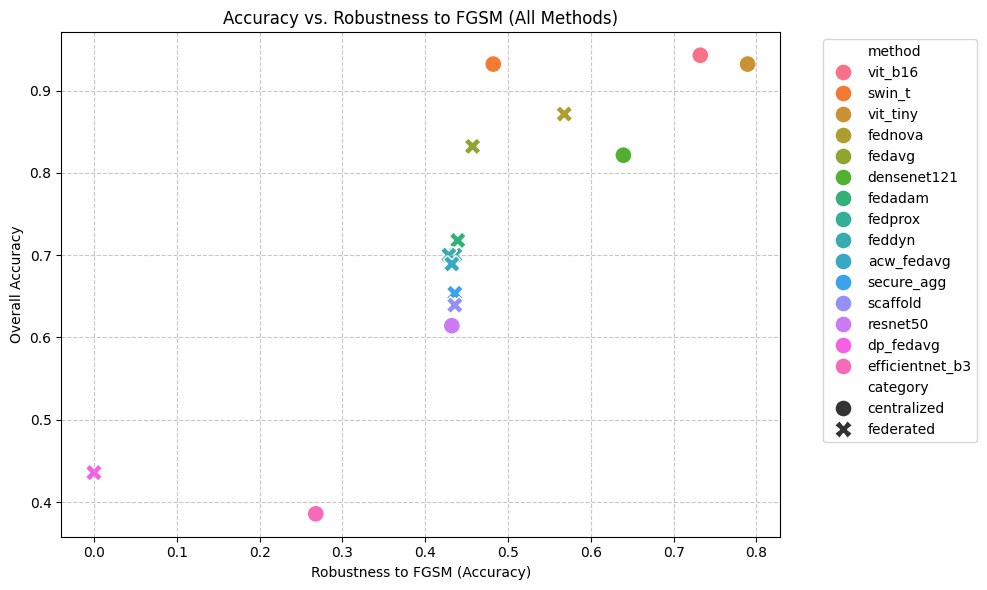

In [87]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='robust_acc_fgsm', y='accuracy', hue='method', style='category', s=150)
plt.title('Accuracy vs. Robustness to FGSM (All Methods)')
plt.xlabel('Robustness to FGSM (Accuracy)')
plt.ylabel('Overall Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [88]:
vit_and_centralized_models = master_df[
    (master_df['category'] == 'centralized') |
    ((master_df['method'] == 'acw_fedavg') & (master_df['category'] == 'federated'))
].copy()

display_cols_for_comparison = [
    'method',
    'category',
    'accuracy',
    'balanced_accuracy',
    'macro_f1',
    'macro_auroc',
    'fairness_acc_gap',
    'robust_acc_gaussian_noise',
    'robust_acc_fgsm'
]

display(vit_and_centralized_models[display_cols_for_comparison].sort_values('accuracy', ascending=False))

,method,category,accuracy,balanced_accuracy,macro_f1,macro_auroc,fairness_acc_gap,robust_acc_gaussian_noise,robust_acc_fgsm
3,vit_b16,centralized,0.942857,0.939850,0.937737,0.997701,0.116276,0.932143,0.732143
4,swin_t,centralized,0.932143,0.928571,0.923810,0.994936,0.162485,0.942857,0.482143
5,vit_tiny,centralized,0.932143,0.928571,0.923810,0.994376,0.037404,0.907143,0.789286
1,densenet121,centralized,0.821429,0.812938,0.808934,0.975270,0.056544,0.375000,0.639286
14,acw_fedavg,federated,0.689286,0.682889,0.612635,0.983268,0.163931,0.710714,0.432143
0,resnet50,centralized,0.614286,0.604064,0.579103,0.920572,0.102143,0.428571,0.432143
2,efficientnet_b3,centralized,0.385714,0.384449,0.384165,0.743513,0.077291,0.232143,0.267857


In [89]:
vit_tiny_fednova_comparison = master_df[
    (master_df['method'] == 'vit_tiny') |
    (master_df['method'] == 'fednova')
].copy()

display_cols_for_comparison = [
    'method',
    'category',
    'accuracy',
    'balanced_accuracy',
    'macro_f1',
    'macro_auroc',
    'fairness_acc_gap',
    'robust_acc_gaussian_noise',
    'robust_acc_fgsm',
    'comm_cost_MB_per_round',
    'membership_inference_auc'
]

display(vit_tiny_fednova_comparison[display_cols_for_comparison].sort_values('accuracy', ascending=False))

,method,category,accuracy,balanced_accuracy,macro_f1,macro_auroc,fairness_acc_gap,robust_acc_gaussian_noise,robust_acc_fgsm,comm_cost_MB_per_round,membership_inference_auc
5,vit_tiny,centralized,0.932143,0.928571,0.92381,0.994376,0.037404,0.907143,0.789286,21.980188,NaN
9,fednova,federated,0.871429,0.864854,0.84972,0.985149,0.053124,0.871429,0.567857,219.801880,0.47719


In [90]:
vit_tiny_fednova_comparison = master_df[
    (master_df['method'] == 'vit_tiny') |
    (master_df['method'] == 'fednova')
].copy()

display_cols_for_comparison = [
    'method',
    'category',
    'accuracy',
    'balanced_accuracy',
    'macro_f1',
    'macro_auroc',
    'fairness_acc_gap',
    'robust_acc_gaussian_noise',
    'robust_acc_fgsm',
    'comm_cost_MB_per_round',
    'membership_inference_auc'
]

display(vit_tiny_fednova_comparison[display_cols_for_comparison].sort_values('accuracy', ascending=False))

,method,category,accuracy,balanced_accuracy,macro_f1,macro_auroc,fairness_acc_gap,robust_acc_gaussian_noise,robust_acc_fgsm,comm_cost_MB_per_round,membership_inference_auc
5,vit_tiny,centralized,0.932143,0.928571,0.92381,0.994376,0.037404,0.907143,0.789286,21.980188,NaN
9,fednova,federated,0.871429,0.864854,0.84972,0.985149,0.053124,0.871429,0.567857,219.801880,0.47719


In [91]:
correlation_acc_mia = fed_only['accuracy'].corr(fed_only['membership_inference_auc'])
print(f"Correlation between Accuracy and Membership Inference AUC for Federated Methods: {correlation_acc_mia:.4f}")

Correlation between Accuracy and Membership Inference AUC for Federated Methods: -0.6608


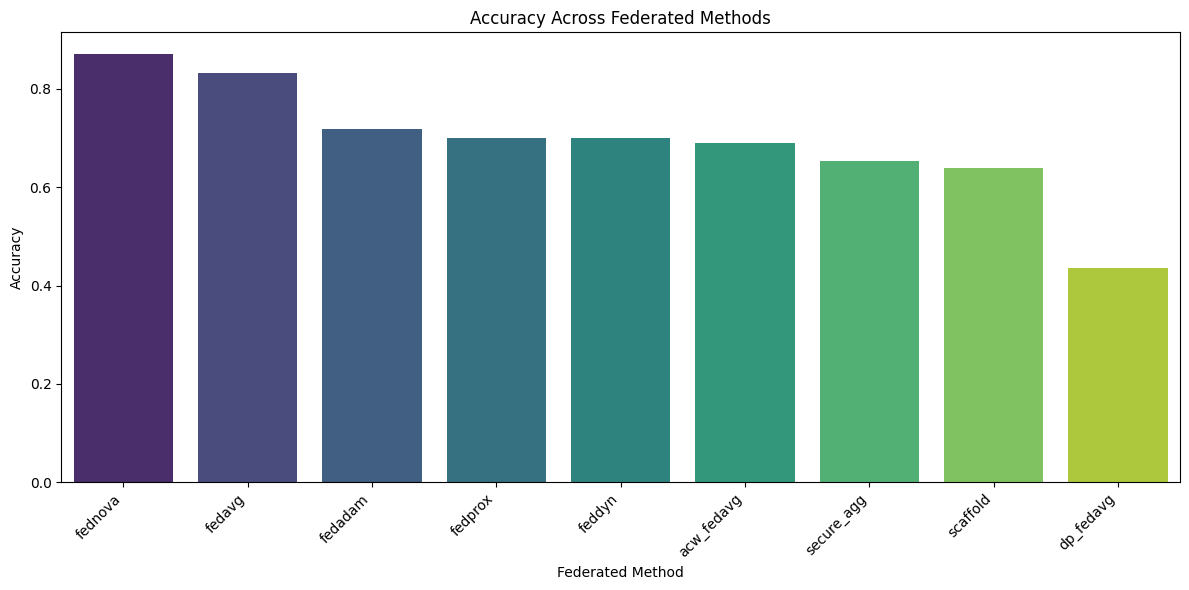

In [93]:
plt.figure(figsize=(12, 6))
sns.barplot(data=fed_only, x='method', y='accuracy', palette='viridis')
plt.title('Accuracy Across Federated Methods')
plt.xlabel('Federated Method')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

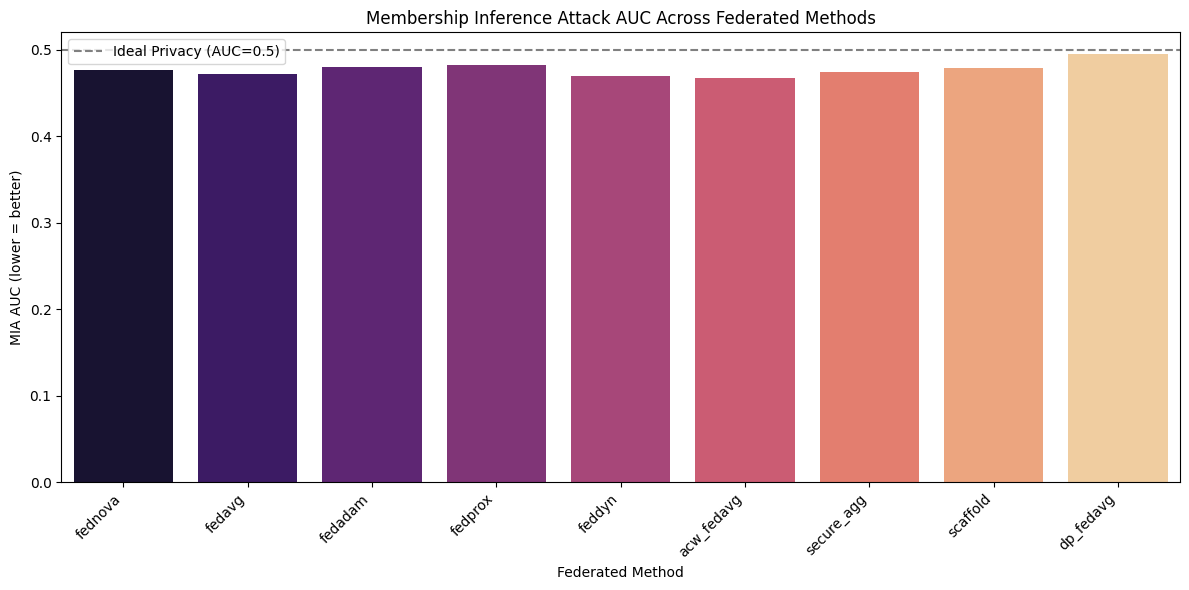

In [94]:
plt.figure(figsize=(12, 6))
sns.barplot(data=fed_only, x='method', y='membership_inference_auc', palette='magma')
plt.axhline(0.5, color='gray', linestyle='--', label='Ideal Privacy (AUC=0.5)')
plt.title('Membership Inference Attack AUC Across Federated Methods')
plt.xlabel('Federated Method')
plt.ylabel('MIA AUC (lower = better)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

In [95]:
correlation_acc_comm_cost = fed_only['accuracy'].corr(fed_only['comm_cost_MB_per_round'])
print(f"Correlation between Accuracy and Communication Cost for Federated Methods: {correlation_acc_comm_cost:.4f}")

Correlation between Accuracy and Communication Cost for Federated Methods: nan


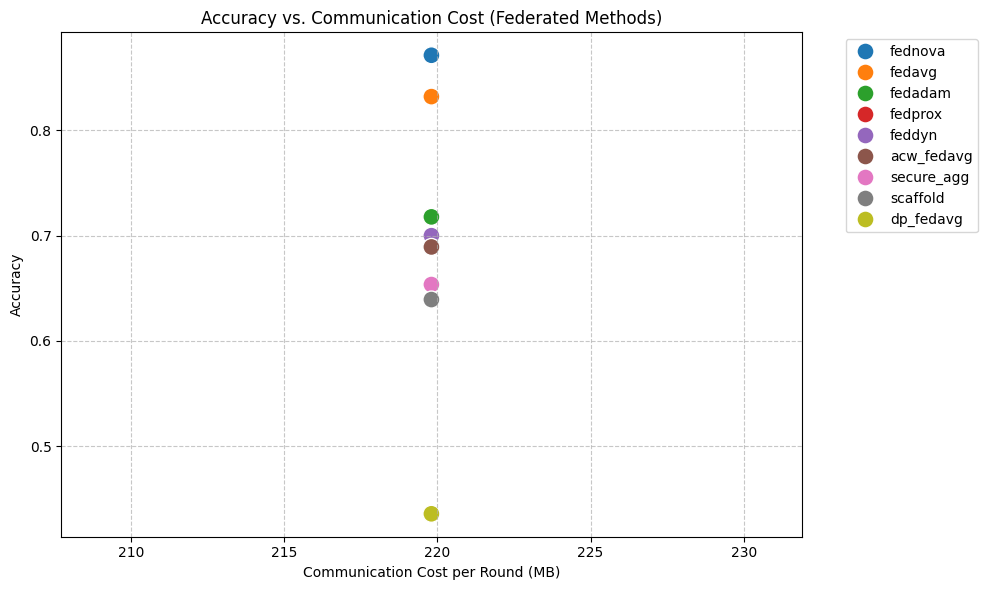

In [96]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=fed_only, x='comm_cost_MB_per_round', y='accuracy', hue='method', s=150)
plt.title('Accuracy vs. Communication Cost (Federated Methods)')
plt.xlabel('Communication Cost per Round (MB)')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

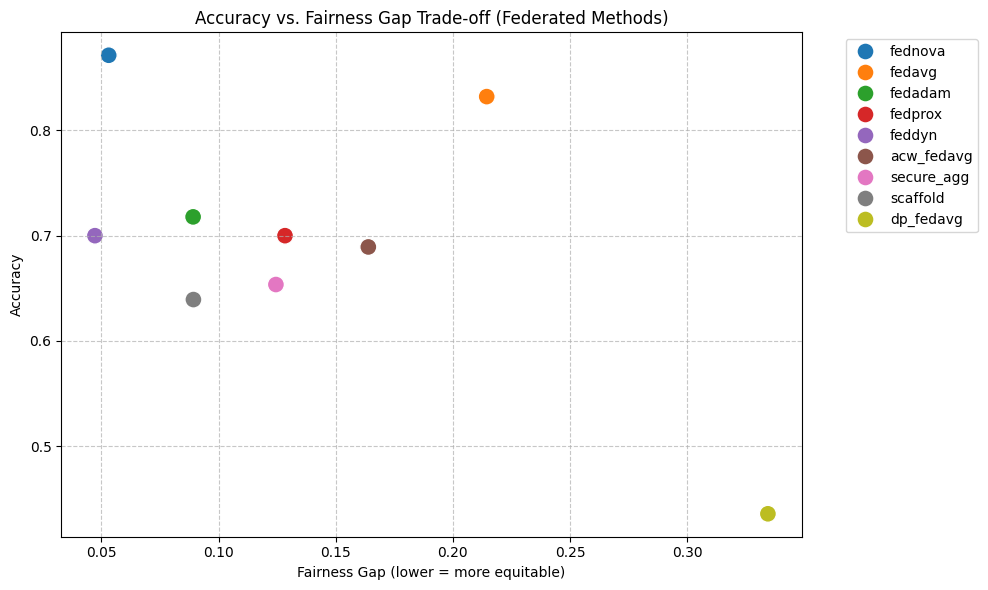

In [97]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=fed_only, x='fairness_acc_gap', y='accuracy', hue='method', s=150)
plt.title('Accuracy vs. Fairness Gap Trade-off (Federated Methods)')
plt.xlabel('Fairness Gap (lower = more equitable)')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [98]:
correlation_fairness_accuracy = master_df['fairness_acc_gap'].corr(master_df['accuracy'])
print(f"Correlation between Fairness Gap and Accuracy: {correlation_fairness_accuracy:.4f}")

Correlation between Fairness Gap and Accuracy: -0.3164


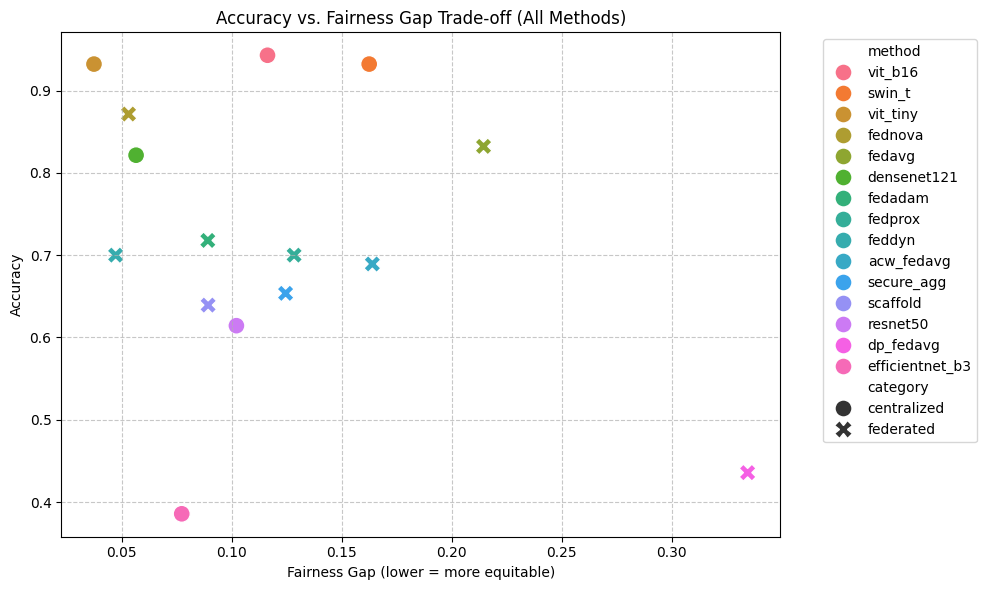

In [99]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master_df, x='fairness_acc_gap', y='accuracy', hue='method', style='category', s=150)
plt.title('Accuracy vs. Fairness Gap Trade-off (All Methods)')
plt.xlabel('Fairness Gap (lower = more equitable)')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

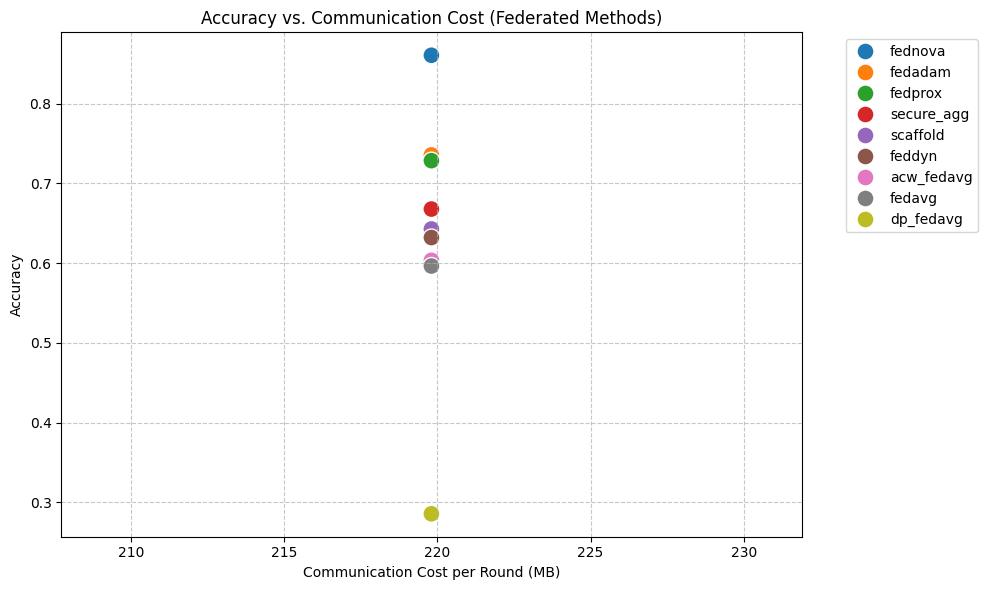

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=fed_only, x='comm_cost_MB_per_round', y='accuracy', hue='method', s=150)
plt.title('Accuracy vs. Communication Cost (Federated Methods)')
plt.xlabel('Communication Cost per Round (MB)')
plt.ylabel('Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [100]:
fed_only = master_df[master_df['category'] == 'federated']
correlation = fed_only['comm_cost_MB_per_round'].corr(fed_only['membership_inference_auc'])
print(f"Correlation between Communication Cost and MIA AUC: {correlation:.4f}")

Correlation between Communication Cost and MIA AUC: nan


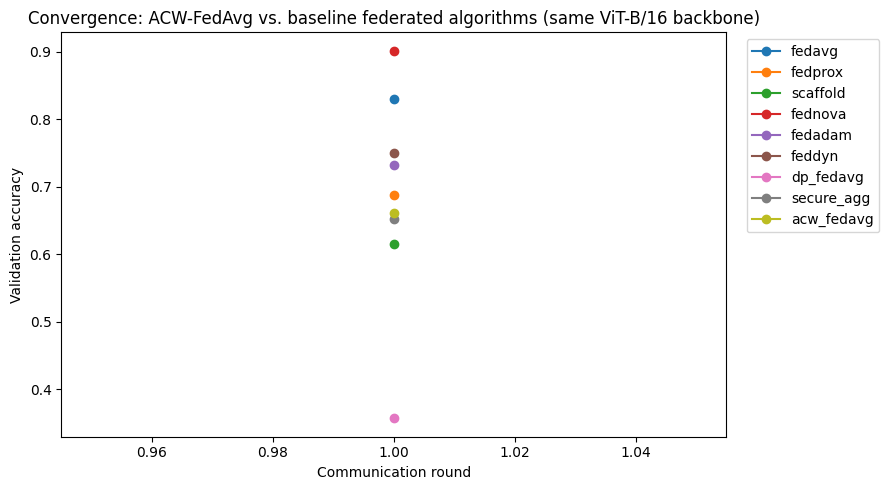

In [101]:
# Convergence curves (accuracy per round) for all federated methods, incl. ACW-FedAvg
plt.figure(figsize=(9, 5))
for method, hist in fed_histories.items():
    accs = [h["accuracy"] for h in hist]
    plt.plot(range(1, len(accs) + 1), accs, marker="o", label=method)
plt.xlabel("Communication round"); plt.ylabel("Validation accuracy")
plt.title("Convergence: ACW-FedAvg vs. baseline federated algorithms (same ViT-B/16 backbone)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{cfg.RESULTS_DIR}/convergence_curves.png", dpi=130)
plt.show()


## 16. Save Everything

In [102]:
master_df.to_csv(f"{cfg.RESULTS_DIR}/master_comparison.csv", index=False)
ablation_df.to_csv(f"{cfg.RESULTS_DIR}/far_acw_fed_ablation.csv", index=False)
xai_df.to_csv(f"{cfg.RESULTS_DIR}/xai_quality_metrics.csv", index=False)
privacy_df.to_csv(f"{cfg.RESULTS_DIR}/membership_inference_privacy.csv", index=False)
with open(f"{cfg.RESULTS_DIR}/llm_explanation_report.txt", "w") as f:
    f.write(report)

print("Saved all results to", cfg.RESULTS_DIR)
!ls -la {cfg.RESULTS_DIR}


Saved all results to /content/results
total 476
drwxr-xr-x 2 root root   4096 Jul 19 09:47 .
drwxr-xr-x 1 root root   4096 Jul 19 05:37 ..
-rw-r--r-- 1 root root  41477 Jul 19 07:10 client_label_dist.png
-rw-r--r-- 1 root root  57243 Jul 19 09:46 convergence_curves.png
-rw-r--r-- 1 root root    790 Jul 19 09:47 far_acw_fed_ablation.csv
-rw-r--r-- 1 root root    673 Jul 19 09:47 llm_explanation_report.txt
-rw-r--r-- 1 root root   3058 Jul 19 09:47 master_comparison.csv
-rw-r--r-- 1 root root 246642 Jul 19 09:35 master_comparison_plots.png
-rw-r--r-- 1 root root    560 Jul 19 09:47 membership_inference_privacy.csv
-rw-r--r-- 1 root root  98692 Jul 19 09:18 xai_comparison.png
-rw-r--r-- 1 root root    140 Jul 19 09:47 xai_quality_metrics.csv


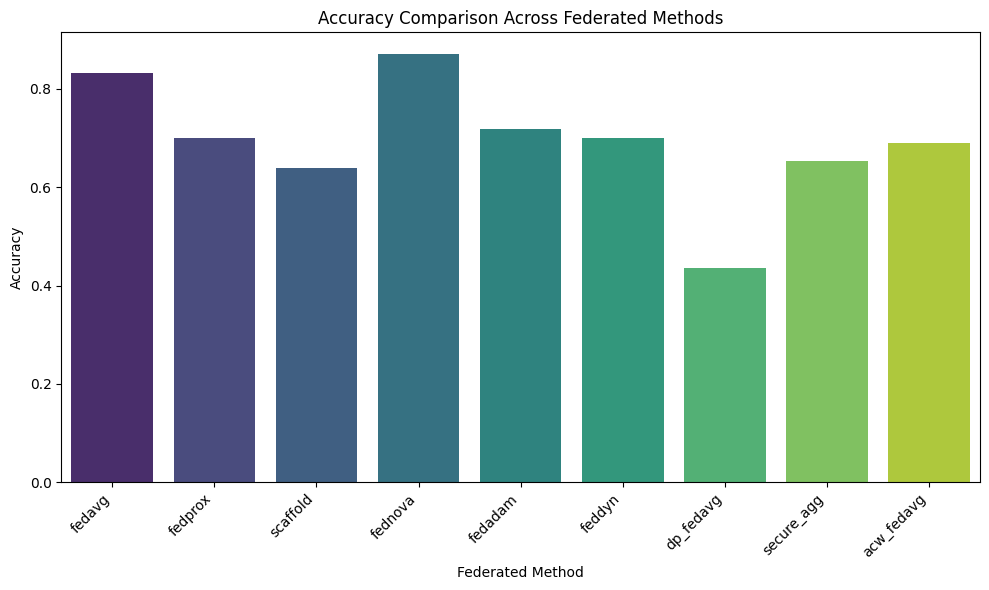

In [103]:
plt.figure(figsize=(10, 6))
sns.barplot(data=federated_df, x='method', y='accuracy', palette='viridis')
plt.title('Accuracy Comparison Across Federated Methods')
plt.xlabel('Federated Method')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

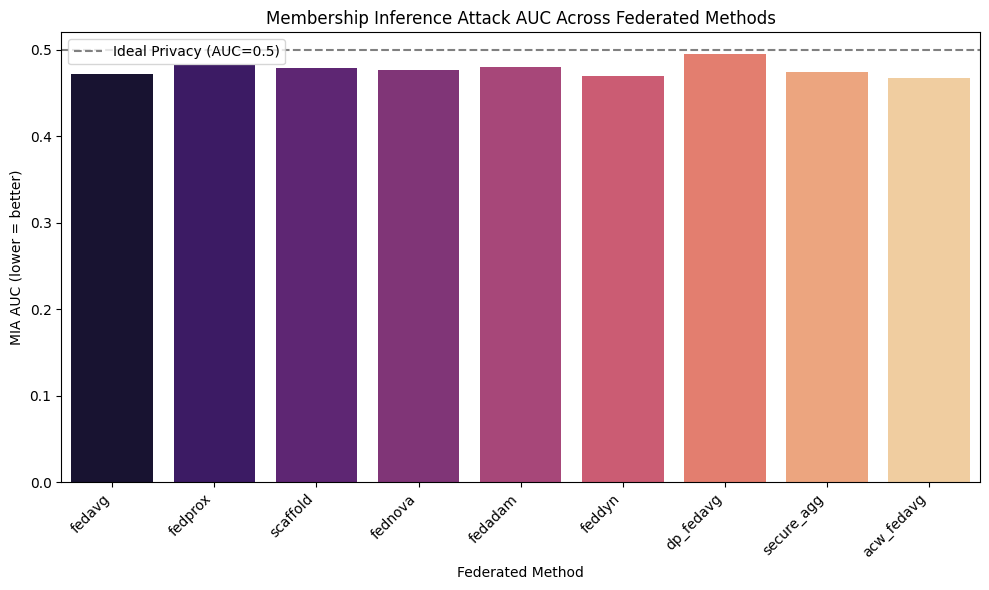

In [104]:
plt.figure(figsize=(10, 6))
sns.barplot(data=privacy_df, x='method', y='membership_inference_auc', palette='magma')
plt.axhline(0.5, color='gray', linestyle='--', label='Ideal Privacy (AUC=0.5)')
plt.title('Membership Inference Attack AUC Across Federated Methods')
plt.xlabel('Federated Method')
plt.ylabel('MIA AUC (lower = better)')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

## 17. Notes on scaling this to a real study

- Set `cfg.QUICK_DEMO = False`, `cfg.USE_REAL_DATA = True` and increase `N_ROUNDS` (50-100), `LOCAL_EPOCHS` (3-5), and `N_CLIENTS` (20-50) for publication-grade numbers.
- For rigorous **differential privacy accounting**, replace the manual noise injection in `dp_fedavg` with `opacus.PrivacyEngine` wrapping each client optimizer, and report `(epsilon, delta)` via `opacus.accountants.RDPAccountant` per round.
- For a stronger **membership inference** baseline, train shadow models (Shokri et al., 2017) rather than the single-threshold attack used here.
- For **statistical rigor**, repeat every run over 3-5 seeds and report mean ± std; a paired t-test or Wilcoxon signed-rank test between `acw_fedavg` and each baseline is recommended for the accuracy/fairness/robustness columns.
- The Attention-Rollout implementation uses forward hooks on `attn_drop` as a lightweight proxy for raw attention weights; for exact fidelity, patch `timm`'s `Attention.forward` to also `return` the attention tensor.
- Swap the template-based LLM explainer for a real API call (`llm_explain(..., use_api=True, api_key=...)`) once you provide credentials — the rest of the reporting pipeline is unchanged.


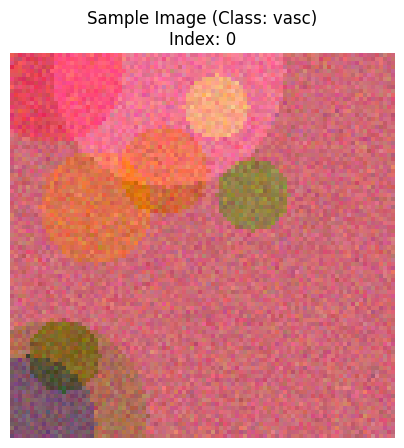

In [105]:
import matplotlib.pyplot as plt
import numpy as np

# Get a sample image and its label from the dataset
sample_index = 0 # You can change this index to view different samples
sample_data = full_dataset[sample_index]
sample_image = sample_data['image']
sample_label = sample_data['label']

# Convert the image tensor to a numpy array for plotting
# The image is normalized to (-1, 1), so we scale it back to (0, 1)
image_np = ((sample_image.permute(1, 2, 0).numpy() * 0.5) + 0.5).clip(0, 1)

# Display the image
plt.figure(figsize=(5, 5))
plt.imshow(image_np)
plt.title(f"Sample Image (Class: {cfg.CLASS_NAMES[sample_label]})\nIndex: {sample_index}")
plt.axis('off')
plt.show()
